# Cardiovascular Disease Prediction
#### Binary Classification: Heart Disease Detection

</br>
<div style="display: flex; justify-content: center; gap: 10px;">
    <div style="text-align: center;">
        <img src="../notebooks/cover2.png" style="width:900px; height:450px;"><br>
    </div>
</div>
</br>

---

Random Seed: 90

Dataset: UCI Heart Disease Dataset (Kaggle)

Core Features: age, trestbps, chol, thalach, oldpeak

Target: target (0=Healthy, 1=Heart Disease)

Models: **Logistic Regression** | **SVM (GridSearch + Optuna)** | **PyTorch MLP** | **CBAM-Enhanced MLP**

Bonus Tracks: 
- *#1* Architectural Upgrades — CBAM Attention Mechanism
- *#2* Hyperparameter Optimization — Optuna Bayesian Search
- *#3* Model Quantization — FP32 → INT8 Dynamic Quantization

---

## 1. Import & Configurations

In [6]:
import time
import os
import warnings
import random
from datetime import datetime

warnings.filterwarnings('ignore')

os.makedirs("../img", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
os.makedirs("../results", exist_ok=True)
os.makedirs("../data", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
import copy
from torch.utils.data import DataLoader, TensorDataset

import missingno as msno
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

**Random Seed Configuration**

In [7]:
RANDOM_SEED = 90

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): #GPU support
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"Random Seed: {RANDOM_SEED}")

Random Seed: 90


**ANSI Color Code Definitions**

In [8]:
GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
BOLD = "\033[1m"

def colorize(value, thresholds=(0.6, 0.8)):
    if value >= thresholds[1]:
        return GREEN
    elif value >= thresholds[0]:
        return YELLOW
    else:
        return RED

def print_metrics(model_name, metrics_dict):
    print(f"\n{BOLD}{'='*50}{RESET}")
    print(f"{BOLD}{model_name}{RESET}")
    print(f"{'='*50}")

    c = colorize(metrics_dict["accuracy_score"])
    print(f"Accuracy:        {c}{metrics_dict['accuracy_score'] * 100:.2f}%{RESET}")

    c = colorize(metrics_dict["f1"])
    print(f"F1 Score:        {c}{metrics_dict['f1'] * 100:.2f}%{RESET}")

    c = colorize(metrics_dict["recall"])
    print(f"Recall:          {c}{metrics_dict['recall'] * 100:.2f}%{RESET}")

    c = colorize(metrics_dict["precision"])
    print(f"Precision:       {c}{metrics_dict['precision'] * 100:.2f}%{RESET}")

    c = colorize(metrics_dict["auc"], (0.7, 0.85))
    print(f"AUC-ROC:         {c}{metrics_dict['auc']:.4f}{RESET}")

    if "n_iter" in metrics_dict:
        print(f"Converged in:    {metrics_dict['n_iter']} iterations")
    print(f"{'='*50}")

---
## 2. Dataset Loading & Preprocessing
#### 2.1. Dataset Loading & Overview
**Load ORIGINAL UCI Cleveland Dataset**

In [19]:
import pandas as pd

# Load the original UCI Cleveland Heart Disease dataset (303 samples)
df = pd.read_csv(
    "../data/heart.data",
    header=None,
    names=[
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
    ],
    na_values='?'
)

print(f"Original rows: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Drop rows with missing values (6 rows dropped → 297 samples)
df = df.dropna().reset_index(drop=True)

# Binary target: 0 = healthy, 1-4 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f"\nAfter dropping NA: {len(df)} rows")
print(f"\nDataset Overview")
print("----------------")
print(f"Total samples : {len(df)}")
print(f"Features (raw): {df.shape[1] - 1}")
print(f"Total columns : {df.shape[1]}")

Original rows: 303
Missing values: 6

After dropping NA: 297 rows

Dataset Overview
----------------
Total samples : 297
Features (raw): 13
Total columns : 14


**Data Preview**

In [20]:
print("\nFirst 5 rows:")
print("-------------")
display(df.head())


First 5 rows:
-------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Target Distribution with Visualization**


Target Distribution
-------------------
target
0    160
1    137
Name: count, dtype: int64


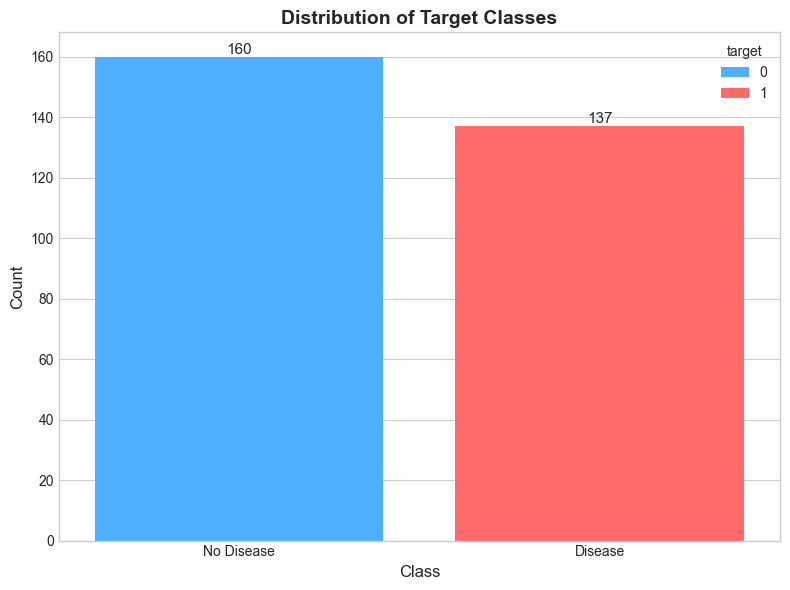

In [ ]:
print("\nTarget Distribution")
print("-------------------")
print(df['target'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    x=df['target'].replace({0: 'No Disease', 1: 'Disease'}),
    palette=["#4DAFFF", "#FF6B6B"],
    saturation=1,
    hue=df['target'],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Target Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../img/01_class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Dataset Information & Data Types**

In [ ]:
print("\nDataset Information:")
print("--------------------\n")
df.info()


Dataset Information:
--------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


#### 2.2. Isolate Core Features
**Feature Isolation**

In [ ]:
CORE_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
TARGET_COLUMN = 'target'

FEATURE_NAMES = {
    'age': 'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved (bpm)',
    'oldpeak': 'ST Depression Induced by Exercise'
}

X = df[CORE_FEATURES].copy().astype(float)
y = df[TARGET_COLUMN].copy().astype(int)

print("\nCore Features:")
print("--------------")
for i, features in enumerate(CORE_FEATURES, 1):
    print(f"  {i}. {features:12s} — {FEATURE_NAMES[features]}")

print(f"\nX shape: {X.shape}, y shape: {y.shape}")


Core Features:
--------------
  1. age          — Age (years)
  2. trestbps     — Resting Blood Pressure (mm Hg)
  3. chol         — Serum Cholesterol (mg/dl)
  4. thalach      — Max Heart Rate Achieved (bpm)
  5. oldpeak      — ST Depression Induced by Exercise

X shape: (297, 5), y shape: (297,)


**Feature Statistics**

In [ ]:
print("\nFeature Statistics:")
print("-------------------")
display(X.describe())


Feature Statistics:
-------------------


,age,trestbps,chol,thalach,oldpeak
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556
std,9.049736,17.762806,51.997583,22.941562,1.166123
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000
75%,61.000000,140.000000,276.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


**Missing Value & Zero Audit**

In [ ]:
print("\nMissing Values:")
print("-----------------")
print(X.isnull().sum())

print("\nZero Value Audit (potential missing indicators):")
print("--------------------------------------------------")
for col in CORE_FEATURES:
    zc = (X[col] == 0).sum()
    print(f"{col:12s}: {zc:3d} zeros ({100*zc/len(X):5.1f}%)")


Missing Values:
-----------------
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
dtype: int64

Zero Value Audit (potential missing indicators):
--------------------------------------------------
age         :   0 zeros (  0.0%)
trestbps    :   0 zeros (  0.0%)
chol        :   0 zeros (  0.0%)
thalach     :   0 zeros (  0.0%)
oldpeak     :  96 zeros ( 32.3%)


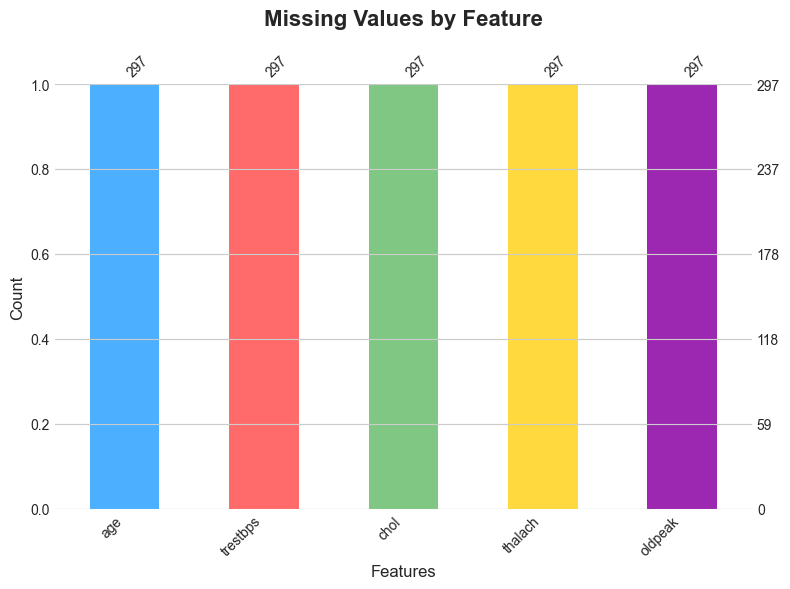

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
msno.bar(
    df[CORE_FEATURES],
    color=["#4DAFFF", '#FF6B6B', '#81C784', '#FFD93D', '#9C27B0'],
    figsize=(8, 6),
    ax=ax
)
ax.set_title("Missing Values by Feature", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

ax.tick_params(axis='both', labelsize=10)

for axis in plt.gcf().axes:
    axis.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("../img/02_missing_values.png", dpi=300, bbox_inches='tight')
plt.show()

**Feature Distribution Analysis & Histograms**

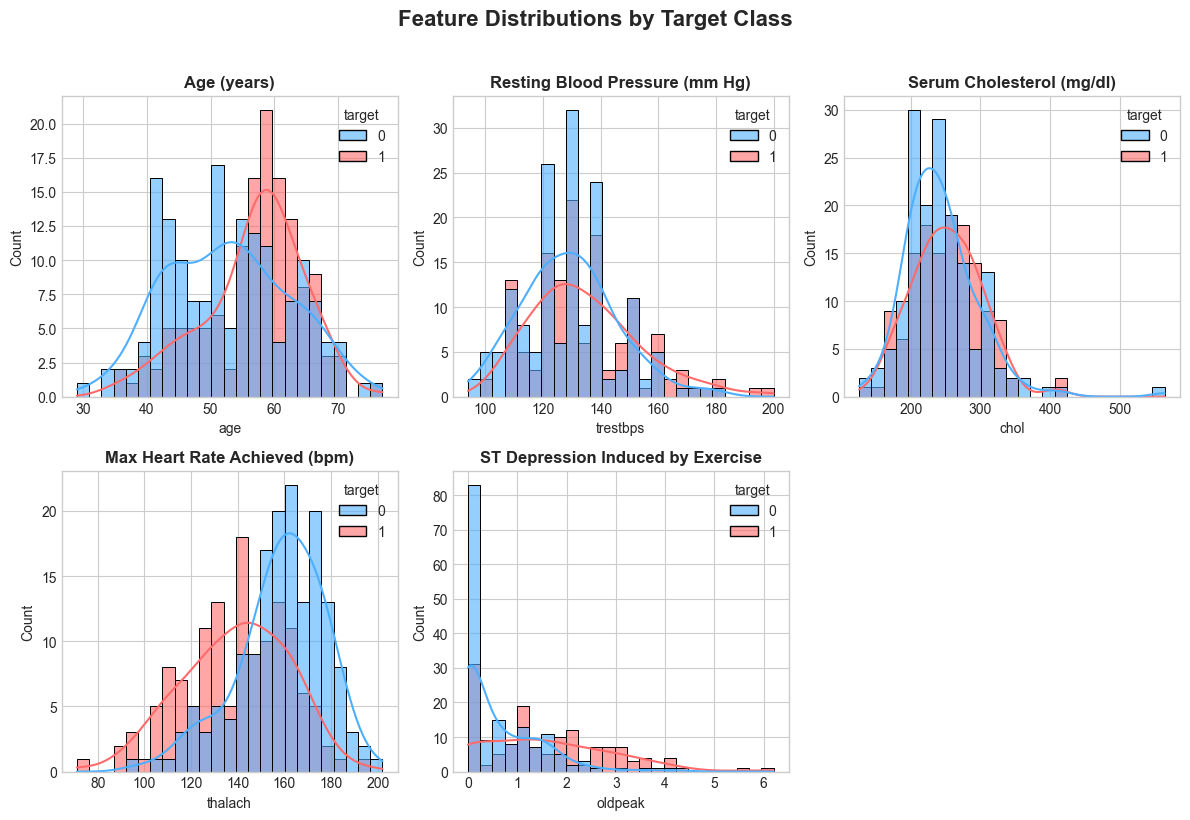

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(CORE_FEATURES):
    sns.histplot(
        data=df, 
        x=feature, 
        hue='target',
        bins=25, 
        kde=True, 
        palette=['#4DAFFF', '#FF6B6B'],
        alpha=0.6, 
        ax=axes[i]
    )
    axes[i].set_title(FEATURE_NAMES[feature], fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)

fig.delaxes(axes[5])
plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../img/03_feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

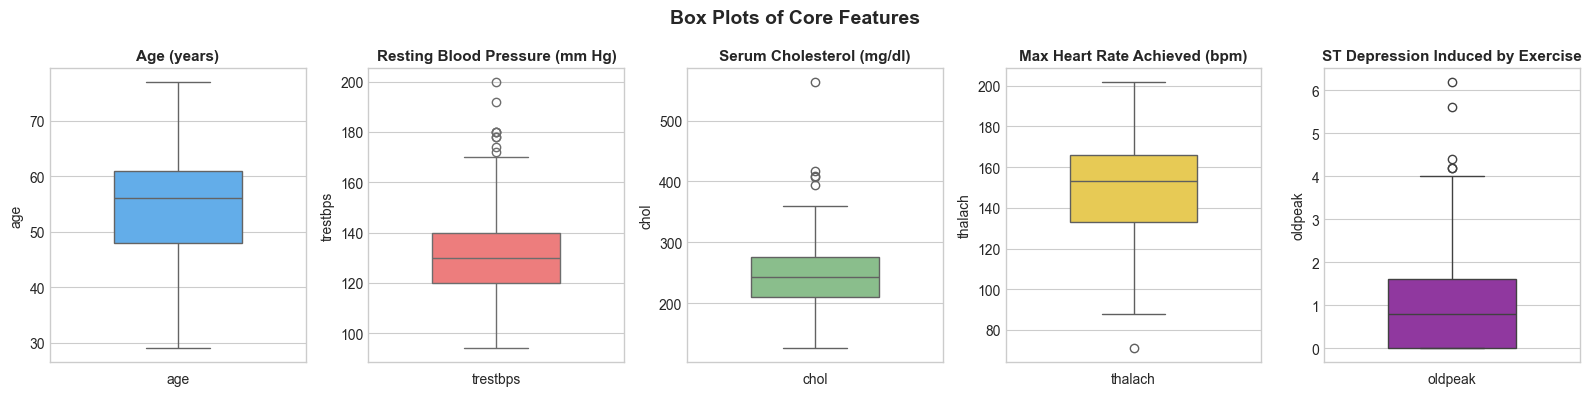

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
colors = ['#4DAFFF', '#FF6B6B', '#81C784', '#FFD93D', '#9C27B0']

for i, feature in enumerate(CORE_FEATURES):
    sns.boxplot(
        y=df[feature], 
        ax=axes[i], 
        color=colors[i], 
        width=0.5)
    
    axes[i].set_title(FEATURE_NAMES[feature], fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    
plt.suptitle('Box Plots of Core Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../img/04_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

**Pairwise Feature Relationships (Pairplot)**

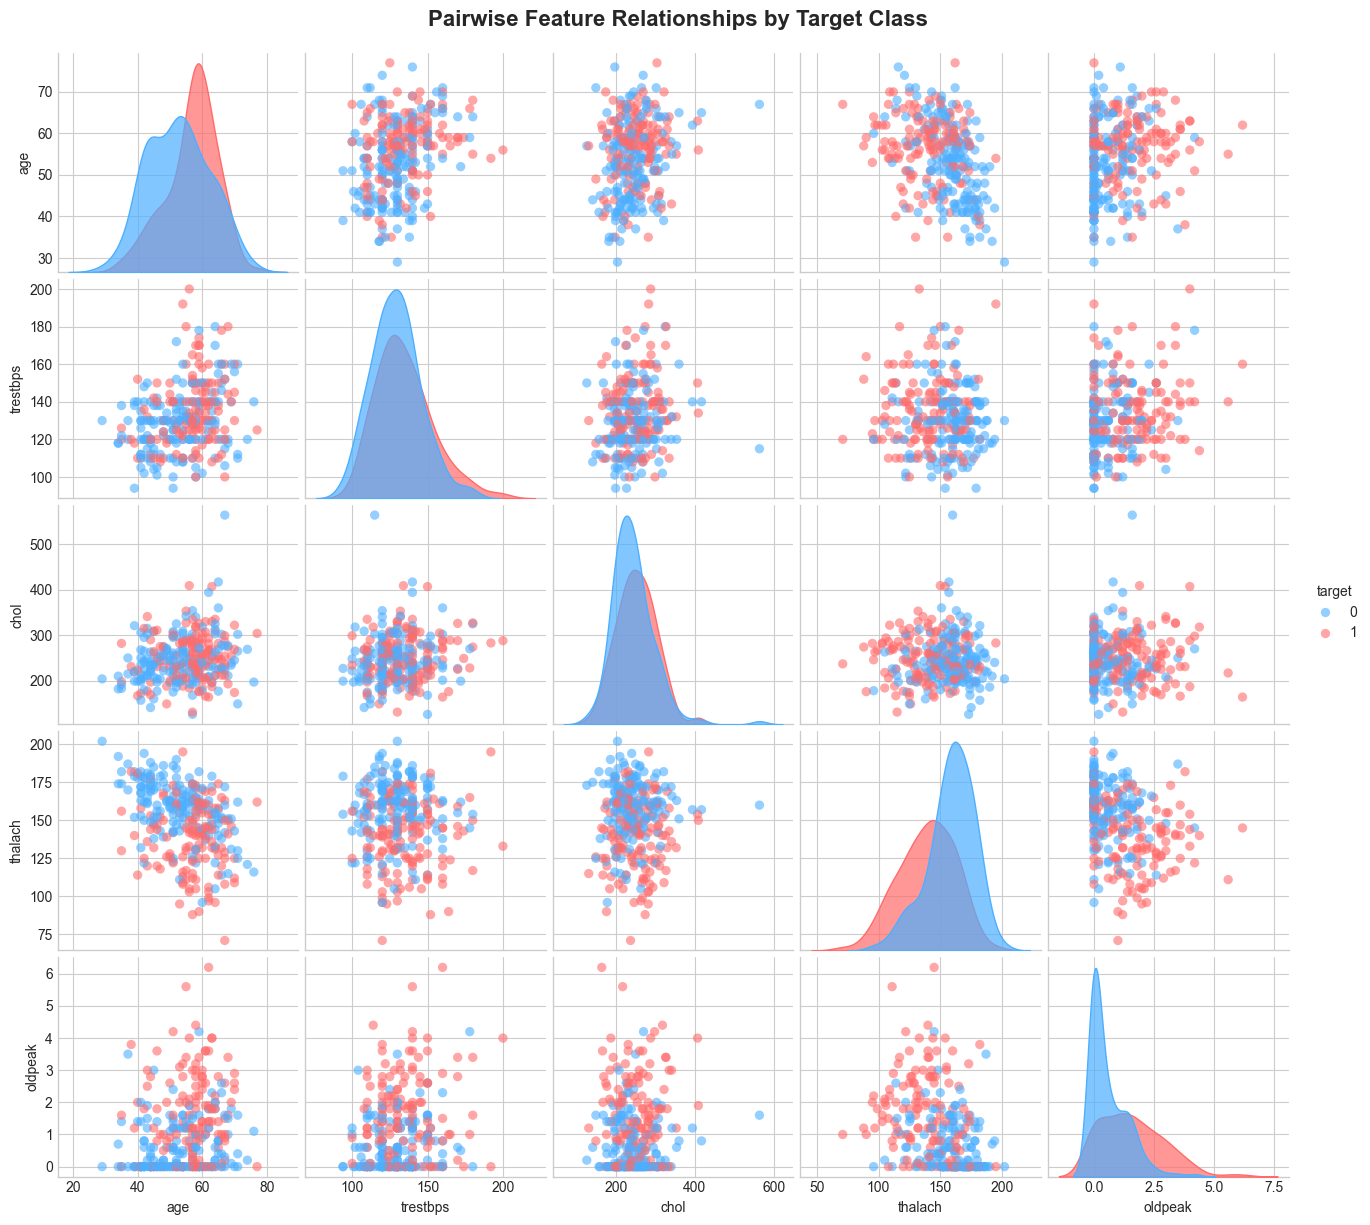

In [ ]:
eda = sns.pairplot(
    df[CORE_FEATURES + ['target']],
    hue='target',
    palette=['#4DAFFF', '#FF6B6B'],
    diag_kind='kde',
    height=2.4,
    aspect=1.1,
    plot_kws={'alpha': 0.6, 's': 45, 'edgecolor': 'none'},
    diag_kws={'alpha': 0.7, 'fill': True}
)
eda.fig.suptitle(
    "Pairwise Feature Relationships by Target Class",
    y=1.02, fontsize=16, fontweight='bold'
)
eda.fig.savefig("../img/05_pairplot.png", dpi=300, bbox_inches='tight')
plt.show()

**Feature Correlation Heatmap**

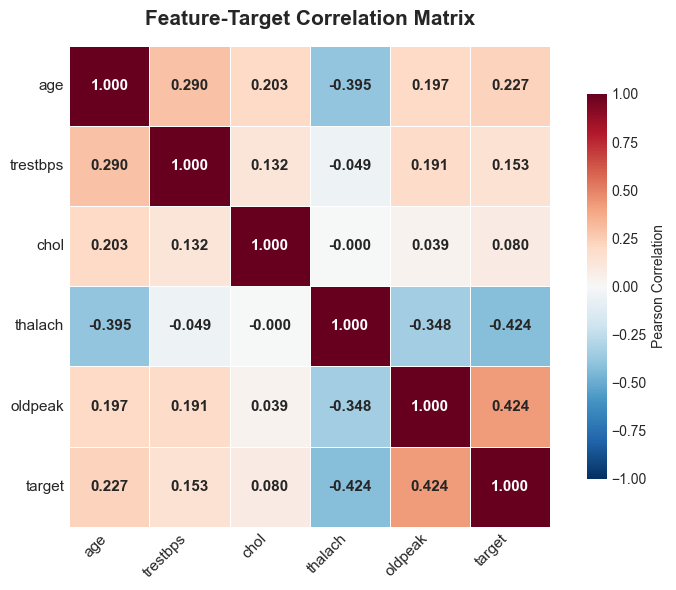

Key Correlations with Target:
-----------------------------
oldpeak     : +0.424 ↑
thalach     : -0.424 ↓
age         : +0.227 ↑
trestbps    : +0.153 ↑
chol        : +0.080 ↑


In [ ]:
plt.figure(figsize=(8, 6))
corr_full = df[CORE_FEATURES + ['target']].corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
sns.heatmap(
    corr_full, 
    annot=True, 
    fmt='.3f', 
    cmap='RdBu_r',
    center=0, 
    square=True, 
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    annot_kws={'size': 11, 'fontweight': 'bold'}
)
plt.title('Feature-Target Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig("../img/06_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("Key Correlations with Target:")
print("-----------------------------")
target_corr = corr_full['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    direction = "↑" if corr > 0 else "↓"
    color = GREEN if corr > 0 else RED
    print(f"{feat:12s}: {corr:+.3f} {color}{direction}{RESET}")

#### 2.3. Train-Test Split & Preprocessing Pipeline
**Train-Test Split (70% / 30%)**

In [ ]:
print("\nTrain-Test Split:")
print("-----------------")
print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y      # Ensure balanced class distribution in both sets
)

print(f"\nTrain set : {X_train.shape[0]} samples ({100*len(X_train)/len(X):.1f}%)")
print(f"Test set  : {X_test.shape[0]} samples ({100*len(X_test)/len(X):.1f}%)")
print(f"\nTrain class distribution:")
print(f"  Healthy (0): {y_train.value_counts().sort_index()[0]} ({100*y_train.value_counts(normalize=True).sort_index()[0]:.1f}%)")
print(f"  Disease (1): {y_train.value_counts().sort_index()[1]} ({100*y_train.value_counts(normalize=True).sort_index()[1]:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Healthy (0): {y_test.value_counts().sort_index()[0]} ({100*y_test.value_counts(normalize=True).sort_index()[0]:.1f}%)")
print(f"  Disease (1): {y_test.value_counts().sort_index()[1]} ({100*y_test.value_counts(normalize=True).sort_index()[1]:.1f}%)")


Train-Test Split:
-----------------
Feature matrix X : (297, 5)
Target vector y  : (297,)

Train set : 207 samples (69.7%)
Test set  : 90 samples (30.3%)

Train class distribution:
  Healthy (0): 112 (54.1%)
  Disease (1): 95 (45.9%)

Test class distribution:
  Healthy (0): 48 (53.3%)
  Disease (1): 42 (46.7%)


#### 2.4. Preprocessing Pipeline — Data Leakage Prevention
**Preprocessing Pipeline**

In [ ]:
print("\nPreprocessing Steps")
print("-------------------")

# Step 1: Median Imputation (fit on train only)
imputer = SimpleImputer(strategy='median')          # Replace missing values using the median of each feature
X_train_imputed = imputer.fit_transform(X_train)    # Learn the median from the training data and replace missing values
X_test_imputed = imputer.transform(X_test)          # Replace missing values in the test data using the training medians

print("\n[STEP 1] Median Imputation")
print(f"  Fitted on: Training set only ({X_train.shape[0]} samples)")
print(f"  Imputation statistics (medians):")
for i, feat in enumerate(CORE_FEATURES):
    print(f"    {feat:12s}: {imputer.statistics_[i]:.3f}")

# Step 2: StandardScaler (fit on train only)
scaler = StandardScaler()                                   # Standardize the features so each has mean 0 and standard deviation 1
X_train_scaled = scaler.fit_transform(X_train_imputed)      # Learn scaling parameters from the training data and standardize it
X_test_scaled = scaler.transform(X_test_imputed)            # Apply the same scaling parameters to the test data

print("\n[STEP 2] StandardScaler (Z-score normalization)")
print(f"  Fitted on: Training set only")
print(f"  Training set statistics:")
for i, feat in enumerate(CORE_FEATURES):
    print(f"    {feat:12s}: μ={scaler.mean_[i]:.3f}, σ={np.sqrt(scaler.var_[i]):.3f}")

# Convert to DataFrames for display
X_train_df = pd.DataFrame(X_train_scaled, columns=CORE_FEATURES, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=CORE_FEATURES, index=X_test.index)

print("\nPreprocessed training data (first 5 rows):")
display(X_train_df.head().round(4))

print("\nPreprocessed test data (first 5 rows):")
display(X_test_df.head().round(4))


Preprocessing Steps
-------------------

[STEP 1] Median Imputation
  Fitted on: Training set only (207 samples)
  Imputation statistics (medians):
    age         : 56.000
    trestbps    : 130.000
    chol        : 240.000
    thalach     : 152.000
    oldpeak     : 0.600

[STEP 2] StandardScaler (Z-score normalization)
  Fitted on: Training set only
  Training set statistics:
    age         : μ=54.633, σ=9.505
    trestbps    : μ=131.860, σ=16.419
    chol        : μ=246.507, σ=53.732
    thalach     : μ=149.860, σ=23.459
    oldpeak     : μ=0.998, σ=1.172

Preprocessed training data (first 5 rows):


,age,trestbps,chol,thalach,oldpeak
91,0.7751,-0.1133,-0.2886,-0.1645,0.6845
135,1.6168,0.8003,-1.3494,-1.0597,1.3669
181,0.4595,2.8101,0.4372,-0.2072,2.7317
162,0.3543,-1.9404,0.0278,-1.1876,0.0021
201,-1.2239,-1.3313,-0.6608,0.4749,-0.8509



Preprocessed test data (first 5 rows):


,age,trestbps,chol,thalach,oldpeak
262,-1.3291,0.2521,1.2747,-1.0597,0.6845
195,-0.4874,-0.7223,-0.0467,0.5175,0.0874
245,-0.2770,-0.4178,-0.6422,0.7733,0.0021
126,-0.0666,-1.3313,-0.1397,-1.0171,1.5375
11,0.1438,0.4958,0.8839,0.1339,0.2580


---
## 3. Model Training & Validation
#### 3.1 Logistic Regression
**Logistic Regression Training**

*Constraints:* Default solver (`lbfgs`), fixed `max_iter=1000`.

In [ ]:
c_values = [0.01, 0.1, 1, 10, 100]
best_C = None
best_score = -1

print("\nCross-Validation Results")
print("------------------------")

for C in c_values:
    
    # Create a Logistic Regression model with the current regularization strength
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        random_state=RANDOM_SEED
    )

    # Evaluate the model using 5-fold stratified cross-validation
    # and compute the F1-score for each fold
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='f1'
    )

    mean_score = scores.mean()
    std_score = scores.std()

    print(f"C={C:<6} | F1={mean_score:.4f} ± {std_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_C = C

print(f"\nBest Hyperparameter")
print(f"Best C: {best_C}")
print(f"Best CV F1: {best_score:.4f}")


Cross-Validation Results
------------------------
C=0.01   | F1=0.5855 ± 0.1379
C=0.1    | F1=0.6132 ± 0.1261
C=1      | F1=0.6141 ± 0.1001
C=10     | F1=0.6141 ± 0.1001
C=100    | F1=0.6141 ± 0.1001

Best Hyperparameter
Best C: 1
Best CV F1: 0.6141


In [ ]:
lr_model = LogisticRegression(
    C=best_C,
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_SEED
)

lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=StratifiedKFold(n_splits=5,                  # Partition data into 5 folds;
                       shuffle=True, 
                       random_state=RANDOM_SEED),
    scoring='accuracy', 
    n_jobs=-1                                       # Parallelize across all CPU cores: each fold trains independently
)

print(
    f"\nCV Accuracy:"
    f"\n------------"
    f"\n  Fold scores: {[f'{s*100:.2f}%' for s in lr_cv_scores]}"
    f"\n  Average : {lr_cv_scores.mean()*100:.2f}%"
    f"\n  Variance: {lr_cv_scores.std()*100:.2f}%"
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]


CV Accuracy:
------------
  Fold scores: ['66.67%', '59.52%', '70.73%', '75.61%', '68.29%']
  Average : 68.16%
  Variance: 5.27%


**Model Evaluation**

In [ ]:
# Metrics
lr_metrics = {
    "accuracy_score": accuracy_score(y_test, lr_pred),
    "precision": precision_score(y_test, lr_pred, zero_division=0),
    "recall": recall_score(y_test, lr_pred, zero_division=0),
    "f1": f1_score(y_test, lr_pred, zero_division=0),
    "auc": roc_auc_score(y_test, lr_pred_proba),
    "n_iter": lr_model.n_iter_[0]
}

print_metrics("Logistic Regression", lr_metrics)

coef_df = pd.DataFrame({
    'Feature': CORE_FEATURES,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Coefficients (sorted by absolute impact):")
print("--------------------------------------------------")
display(coef_df)
print(f"Intercept (bias): {lr_model.intercept_[0]:.4f}")


Logistic Regression
Accuracy:        75.56%
F1 Score:        74.42%
Recall:          76.19%
Precision:       72.73%
AUC-ROC:         0.8442
Converged in:    6 iterations

Feature Coefficients (sorted by absolute impact):
--------------------------------------------------


,Feature,Coefficient,Odds_Ratio
4,oldpeak,0.673634,1.961352
3,thalach,-0.642749,0.525845
2,chol,0.171020,1.186514
0,age,0.162747,1.176739
1,trestbps,0.161512,1.175286


Intercept (bias): -0.1685


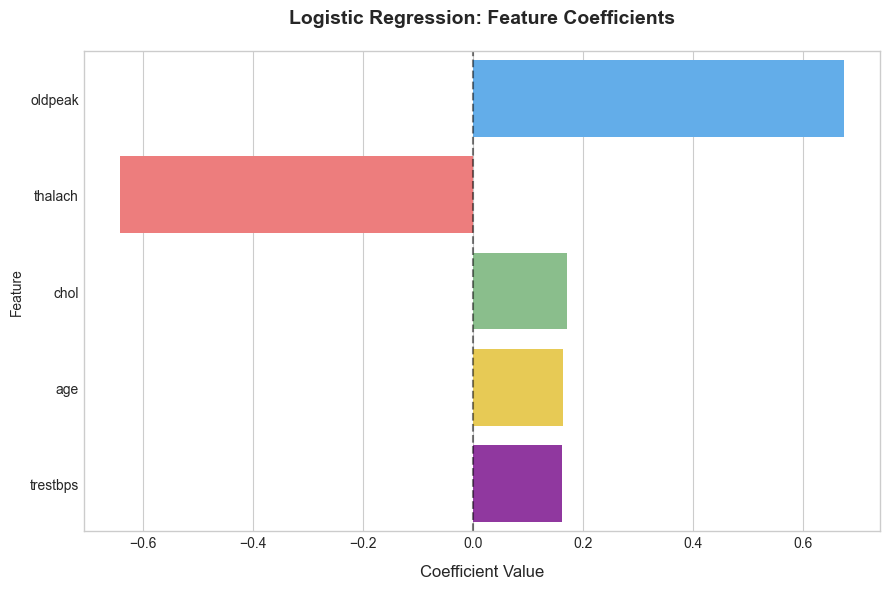

Feature importance Rankings:
----------------------------
  oldpeak     : +0.6736 (↑ increases disease probability)
  thalach     : -0.6427 (↓ decreases disease probability)
  chol        : +0.1710 (↑ increases disease probability)
  age         : +0.1627 (↑ increases disease probability)
  trestbps    : +0.1615 (↑ increases disease probability)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=coef_df, 
    x='Coefficient', 
    y='Feature',
    hue='Feature', 
    palette=colors, 
    legend=False, 
    ax=ax
)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Logistic Regression: Feature Coefficients', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Coefficient Value', fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("../img/07_lr_coefficients.png", dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance Rankings:")
print("----------------------------")
for _, row in coef_df.iterrows():
    direction = "↑ increases" if row['Coefficient'] > 0 else "↓ decreases"
    dir_color = GREEN if row['Coefficient'] > 0 else RED
    print(f"  {row['Feature']:12s}: {row['Coefficient']:+.4f} ({dir_color}{direction}{RESET} disease probability)")

In [ ]:
joblib.dump(lr_model, "../models/01_logistic_regression.pkl")
print(f"\nModel saved: ../models/01_logistic_regression.pkl")


Model saved: ../models/01_logistic_regression.pkl


In [ ]:
print("\nPer-class Classification Report - LR")
print("------------------------------------\n")
print(classification_report(y_test, lr_pred))


Per-class Classification Report - LR
------------------------------------

              precision    recall  f1-score   support

           0       0.78      0.75      0.77        48
           1       0.73      0.76      0.74        42

    accuracy                           0.76        90
   macro avg       0.75      0.76      0.76        90
weighted avg       0.76      0.76      0.76        90



#### 3.2. SVM With Grid Search
**SVM Training**

*Constraints:* Maximum 20 hyperparameter configurations.

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

n_configs = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel']) * len(param_grid['class_weight'])
print("\nSVM GridSearch")
print("--------------")
print(f"Total configurations: {n_configs} (max allowed: 20)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_SEED), # Enable Platt scaling: fits sigmoid P(y=1|x) = 1/(1+exp(A·f(x)+B)) to SVM decision values f(x)=w·φ(x)+b
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

svm_grid.fit(X_train_scaled, y_train)

svm_best = svm_grid.best_estimator_
print(f"\nBest parameters: {svm_grid.best_params_}")
print(f"Best CV accuracy: {svm_grid.best_score_ * 100:.2f}%")

# Predictions
svm_train_pred = svm_best.predict(X_train_scaled)
svm_pred = svm_best.predict(X_test_scaled)
svm_pred_proba = svm_best.predict_proba(X_test_scaled)[:, 1]


SVM GridSearch
--------------
Total configurations: 20 (max allowed: 20)

Best parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 71.53%


**Model Evaluation**

In [ ]:
# Metrics
svm_metrics = {
    "accuracy_score": accuracy_score(y_test, svm_pred),
    "precision": precision_score(y_test, svm_pred, zero_division=0),
    "recall": recall_score(y_test, svm_pred, zero_division=0),
    "f1": f1_score(y_test, svm_pred, zero_division=0),
    "auc": roc_auc_score(y_test, svm_pred_proba)
}

print_metrics("SVM (GridSearch)", svm_metrics)


SVM (GridSearch)
Accuracy:        73.33%
F1 Score:        72.73%
Recall:          76.19%
Precision:       69.57%
AUC-ROC:         0.8279


**SVM Grid Search Heatmap**

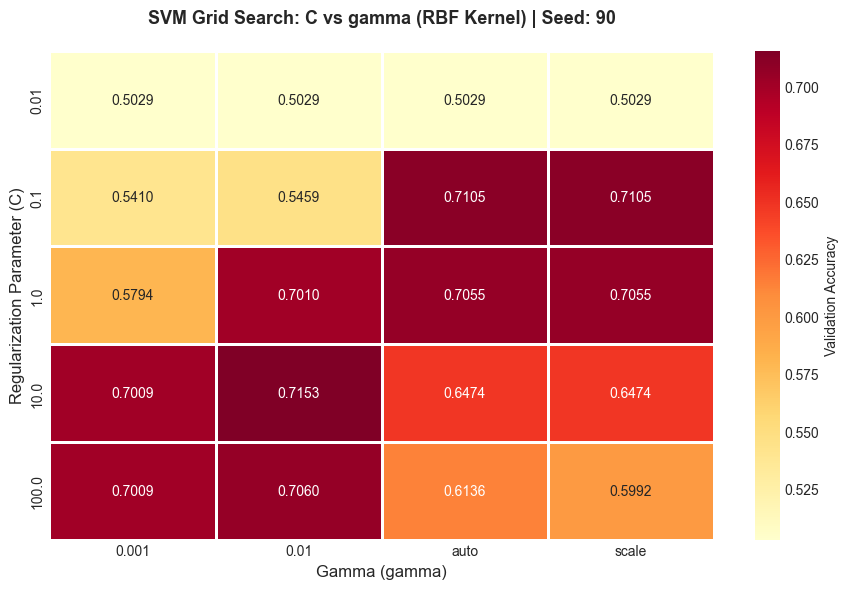

In [ ]:
# Grid Search Heatmap (C vs gamma for RBF kernel)
results_df = pd.DataFrame(svm_grid.cv_results_)
rbf_results = results_df[results_df['param_kernel'] == 'rbf'].copy()

heatmap_data = rbf_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.4f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Validation Accuracy'},
    linewidths=1, 
    linecolor='white',
    ax=ax, 
    vmin=heatmap_data.min().min(), 
    vmax=heatmap_data.max().max()
)
ax.set_title(f'SVM Grid Search: C vs gamma (RBF Kernel) | Seed: {RANDOM_SEED}', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Gamma (gamma)', fontsize=12)
ax.set_ylabel('Regularization Parameter (C)', fontsize=12)
plt.tight_layout()
plt.savefig('../img/08_svm_grid_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print("\nPer-class Classification Report - SVM")
print("-------------------------------------\n")
print(classification_report(y_test, svm_pred))


Per-class Classification Report - SVM
-------------------------------------

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        48
           1       0.70      0.76      0.73        42

    accuracy                           0.73        90
   macro avg       0.73      0.74      0.73        90
weighted avg       0.74      0.73      0.73        90



In [ ]:
joblib.dump(svm_best, "../models/02_svm_gridsearch.pkl")

svm_grid_imp = permutation_importance(svm_grid, X_test_scaled, y_test, n_repeats=10, random_state=RANDOM_SEED)
joblib.dump(svm_grid_imp.importances_mean, '../models/svm_grid_importance.pkl')

print(f"\nModel saved: ../models/02_svm_gridsearch.pkl")


Model saved: ../models/02_svm_gridsearch.pkl


#### 3.3 SVM Hyperparameter Optimization with Optuna

*Tool:* Optuna — Bayesian optimization for hyperparameter search.

In [ ]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def svm_objective(trial):
    C = trial.suggest_float("C", 0.01, 200, log=True)
    gamma = trial.suggest_float("gamma", 0.0001, 10, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "linear"])

    model = SVC(
        kernel=kernel,
        C=C,
        gamma=gamma,
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_SEED
    )

    score = cross_val_score(
        model, X_train_scaled, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="accuracy", 
        n_jobs=-1,
    ).mean()

    return score

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED)         Bayesian optimizer: learns from past trials
)

study.optimize(svm_objective, n_trials=20)

print()
print("Best params:", study.best_params)
print(f'Best CV score: {study.best_value * 100:.4f}%')

best_optuna_svm = SVC(
    kernel=study.best_params["kernel"],
    C=study.best_params["C"],
    gamma=study.best_params["gamma"],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_SEED
)
best_optuna_svm.fit(X_train_scaled, y_train)

# Predictions
optuna_train_pred = best_optuna_svm.predict(X_train_scaled)
optuna_pred = best_optuna_svm.predict(X_test_scaled)
optuna_pred_proba = best_optuna_svm.predict_proba(X_test_scaled)[:, 1]


Best params: {'C': 17.567328113453108, 'gamma': 0.03163167501273658, 'kernel': 'rbf'}
Best CV score: 72.5087%


**Model Evaluation**

In [ ]:
# Metrics
optuna_metrics = {
    "accuracy_score": accuracy_score(y_test, optuna_pred),
    "precision": precision_score(y_test, optuna_pred, zero_division=0),
    "recall": recall_score(y_test, optuna_pred, zero_division=0),
    "f1": f1_score(y_test, optuna_pred, zero_division=0),
    "auc": roc_auc_score(y_test, optuna_pred_proba)
}

print_metrics("SVM (Optuna)", optuna_metrics)


SVM (Optuna)
Accuracy:        72.22%
F1 Score:        72.53%
Recall:          78.57%
Precision:       67.35%
AUC-ROC:         0.7976


In [ ]:
print("\nPer-class Classification Report - SVM Optuna")
print("--------------------------------------------\n")
print(classification_report(y_test, optuna_pred))


Per-class Classification Report - SVM Optuna
--------------------------------------------

              precision    recall  f1-score   support

           0       0.78      0.67      0.72        48
           1       0.67      0.79      0.73        42

    accuracy                           0.72        90
   macro avg       0.73      0.73      0.72        90
weighted avg       0.73      0.72      0.72        90



In [ ]:
comparison_svm = pd.DataFrame({
    "Method": ["GridSearch", "Optuna (Bayesian)"],
    "Best C": [svm_grid.best_params_["C"], round(study.best_params["C"], 4)],
    "Best γ": [svm_grid.best_params_["gamma"], round(study.best_params["gamma"], 6)],
    "Kernel": [svm_grid.best_params_["kernel"], study.best_params["kernel"]],
    "CV Accuracy (%)": [round(svm_grid.best_score_*100, 2), round(study.best_value*100, 2)],
    "Accuracy (%)": [round(svm_metrics["accuracy_score"]*100, 2), round(optuna_metrics["accuracy_score"]*100, 2)],
    "Test F1 (%)": [round(svm_metrics["f1"]*100, 2), round(optuna_metrics["f1"]*100, 2)]
})

print("\nGridSearch vs Optuna Comparison")
print("-------------------------------")
display(comparison_svm)


GridSearch vs Optuna Comparison
-------------------------------


,Method,Best C,Best γ,Kernel,CV Accuracy (%),Accuracy (%),Test F1 (%)
0,GridSearch,10.0000,0.010000,rbf,71.53,73.33,72.73
1,Optuna (Bayesian),17.5673,0.031632,rbf,72.51,72.22,72.53


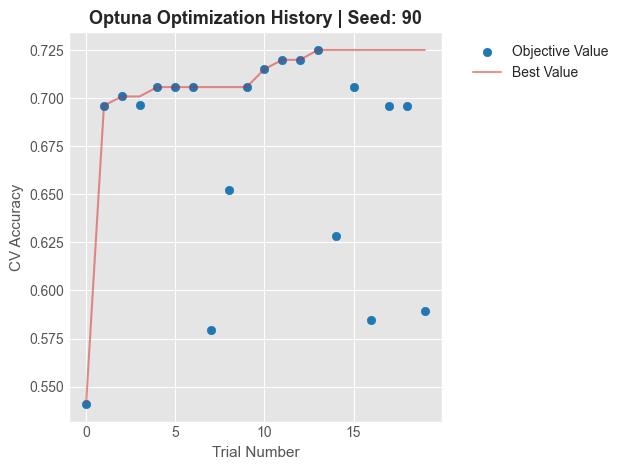

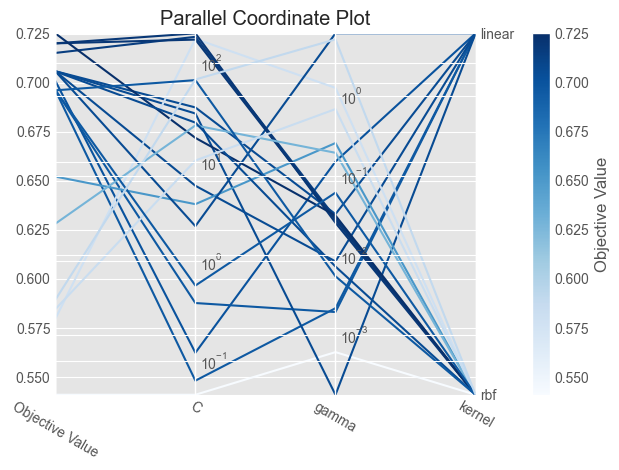

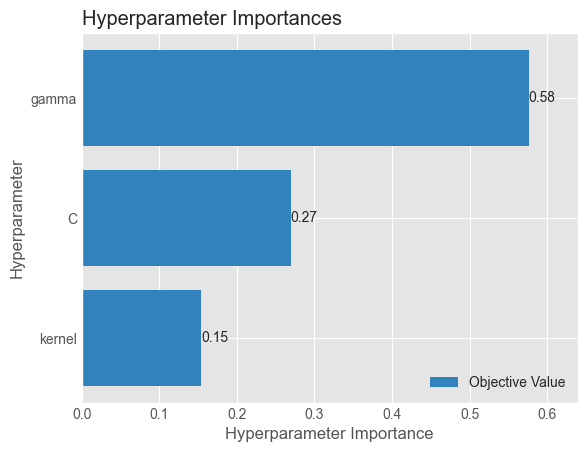

In [ ]:
import optuna.visualization.matplotlib as vis

# 1. Optimization History
fig = vis.plot_optimization_history(study)
plt.title(f'Optuna Optimization History | Seed: {RANDOM_SEED}', fontsize=13, fontweight='bold')
plt.xlabel('Trial Number', fontsize=11)
plt.ylabel('CV Accuracy', fontsize=11)
plt.tight_layout()
plt.savefig('../img/09_optuna_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Parallel Coordinates Plot
fig = vis.plot_parallel_coordinate(study)
plt.tight_layout()
plt.savefig('../img/10_optuna_parallel_coords.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Hyperparameter Importance
fig = vis.plot_param_importances(study)
plt.savefig('../img/11_optuna_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from torch.optim import RAdam


joblib.dump(best_optuna_svm, "../models/03_svm_optuna.pkl")

svm_optuna_imp = permutation_importance(best_optuna_svm, X_test_scaled, y_test, n_repeats=10, random_state=RANDOM_SEED)
joblib.dump(svm_optuna_imp.importances_mean, '../models/svm_optuna_importance.pkl')

print(f"\nModel saved: ../models/03_svm_optuna.pkl")


Model saved: ../models/03_svm_optuna.pkl


#### 3.3 PyTorch MLP Architecture
**MLP Architectural**

In [ ]:
class HeartDiseaseMLP(nn.Module):
    def __init__(self, input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3):
        super(HeartDiseaseMLP, self).__init__()

        # Layer 1: Input → Hidden(32)
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)  # BatchNorm for stability, normalizes each neuron's activations across the batch
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        # Layer 2: Hidden(32) → Hidden(16)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)  # BatchNorm for stability
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        # Layer 3: Hidden(16) → Output(1)
        self.fc3 = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Layer 1: z1 = W1·x + b1, a1 = ReLU(BN(z1)), a1 = Dropout(a1)
        z1 = self.fc1(x)
        a1 = self.relu1(self.bn1(z1))
        a1 = self.dropout1(a1)

        # Layer 2: z2 = W2·a1 + b2, a2 = ReLU(BN(z2)), a2 = Dropout(a2)
        z2 = self.fc2(a1)
        a2 = self.relu2(self.bn2(z2))
        a2 = self.dropout2(a2)

        # Output: z3 = W3·a2 + b3, ŷ = σ(z3)
        z3 = self.fc3(a2)
        y_hat = self.sigmoid(z3)

        return y_hat


torch.manual_seed(RANDOM_SEED)
mlp_model = HeartDiseaseMLP(input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3)

print("\nMLP ARCHITECTURE")
print("----------------\n")
print(mlp_model)

total_params = sum(p.numel() for p in mlp_model.parameters())
trainable_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)

print(f"\nParameter Count:")
print("----------------")
print(f"  Total parameters:     {total_params}")
print(f"  Trainable parameters: {trainable_params}")

print(f"\nLayer-wise breakdown:")
print("---------------------")
for name, param in mlp_model.named_parameters():
    print(f"  {name:20s} {str(tuple(param.shape)):20s} → {param.numel():5d} params")


MLP ARCHITECTURE
----------------

HeartDiseaseMLP(
  (fc1): Linear(in_features=5, out_features=32, bias=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Parameter Count:
----------------
  Total parameters:     833
  Trainable parameters: 833

Layer-wise breakdown:
---------------------
  fc1.weight           (32, 5)              →   160 params
  fc1.bias             (32,)                →    32 params
  bn1.weight           (32,)                →    32 params
  bn1.bias             (32,)                →    32 params
  fc2.weight           (16, 32)             →   

**MLP Data Preparation**

In [ ]:
X_train_mlp, X_val_mlp, y_train_mlp, y_val_mlp = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print(f"\nMLP Data Splits:")
print("----------------")
print(f"  Train:      {len(X_train_mlp)} samples")
print(f"  Validation: {len(X_val_mlp)} samples")
print(f"  Test:       {len(X_test_scaled)} samples")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_mlp)
y_train_t = torch.FloatTensor(y_train_mlp.values).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_mlp)
y_val_t = torch.FloatTensor(y_val_mlp.values).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test.values).unsqueeze(1)

# Verify shapes
print(f"\nTensor shapes:")
print(f"  X_train: {tuple(X_train_t.shape)}, y_train: {tuple(y_train_t.shape)}")
print(f"  X_val:   {tuple(X_val_t.shape)}, y_val:   {tuple(y_val_t.shape)}")
print(f"  X_test:  {tuple(X_test_t.shape)}, y_test:  {tuple(y_test_t.shape)}")

# Create DataLoaders
BATCH_SIZE = 8  # Small batch for small dataset
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders:")
print("------------")
print(f"  Train batches: {len(train_loader)} (batch size: {BATCH_SIZE})")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


MLP Data Splits:
----------------
  Train:      175 samples
  Validation: 32 samples
  Test:       90 samples

Tensor shapes:
  X_train: (175, 5), y_train: (175, 1)
  X_val:   (32, 5), y_val:   (32, 1)
  X_test:  (90, 5), y_test:  (90, 1)

DataLoaders:
------------
  Train batches: 22 (batch size: 8)
  Val batches:   4
  Test batches:  12


**MLP Training**

In [ ]:
# Compute class weights for BCELoss
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], dtype=torch.float32)
print(f"Class weights: {class_weights}")
print(f"Pos weight for BCELoss: {pos_weight.item():.4f}")

LEARNING_RATE = 0.001
MAX_EPOCHS = 200
PATIENCE = 10
WEIGHT_DECAY = 1e-5

torch.manual_seed(RANDOM_SEED)
mlp_model = HeartDiseaseMLP(input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3)

criterion = nn.BCELoss(weight=pos_weight)  # FIX: Add class weights

# Optimizer: Adam with L2 regularization (weight decay)
optimizer = optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Tracking tracking
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
best_model_state = None

print(f"Training config: LR={LEARNING_RATE}, Batch={BATCH_SIZE}, MaxEpochs={MAX_EPOCHS}, Patience={PATIENCE}")
print("-" * 65)

# Training loop
for epoch in range(MAX_EPOCHS):
    # TRAINING PHASE
    mlp_model.train()  # Enable dropout
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    for bx, by in train_loader:
        # Forward pass for prediction
        out = mlp_model(bx)
        loss = criterion(out, by)
        
        # Backward pass for gradient computation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # Update parameters
        
        # Accumulate metrics
        epoch_loss += loss.item() * bx.size(0)
        correct += ((out >= 0.5).float() == by).sum().item()
        total += by.size(0)
    
    train_loss = epoch_loss / total
    train_acc = correct / total
    
    # VALIDATION PHASE
    mlp_model.eval()  # Disable dropout
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():  # No gradient computation
        for bx, by in val_loader:
            out = mlp_model(bx)
            loss = criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            val_correct += ((out >= 0.5).float() == by).sum().item()
            val_total += by.size(0)
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Progress print
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = copy.deepcopy(mlp_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch + 1}")
            break

# Load best model
if best_model_state:
    mlp_model.load_state_dict(best_model_state)
    print(f"\nLoaded best model from epoch {best_epoch + 1}")

print(f"Total epochs trained: {len(train_losses)}")

Class weights: [0.92410714 1.08947368]
Pos weight for BCELoss: 1.1789
Training config: LR=0.001, Batch=8, MaxEpochs=200, Patience=10
-----------------------------------------------------------------
Epoch   1/200 | Train Loss: 0.7827 | Val Loss: 0.7649 | Train Acc: 0.6286 | Val Acc: 0.6562
Epoch  10/200 | Train Loss: 0.7037 | Val Loss: 0.6746 | Train Acc: 0.6571 | Val Acc: 0.5938
Epoch  20/200 | Train Loss: 0.6980 | Val Loss: 0.6752 | Train Acc: 0.6571 | Val Acc: 0.5625

Early stopping triggered at epoch 22
Best validation loss: 0.6737 at epoch 12

Loaded best model from epoch 12
Total epochs trained: 22


**Loss Convergence Curves & Overfitting Analysis**

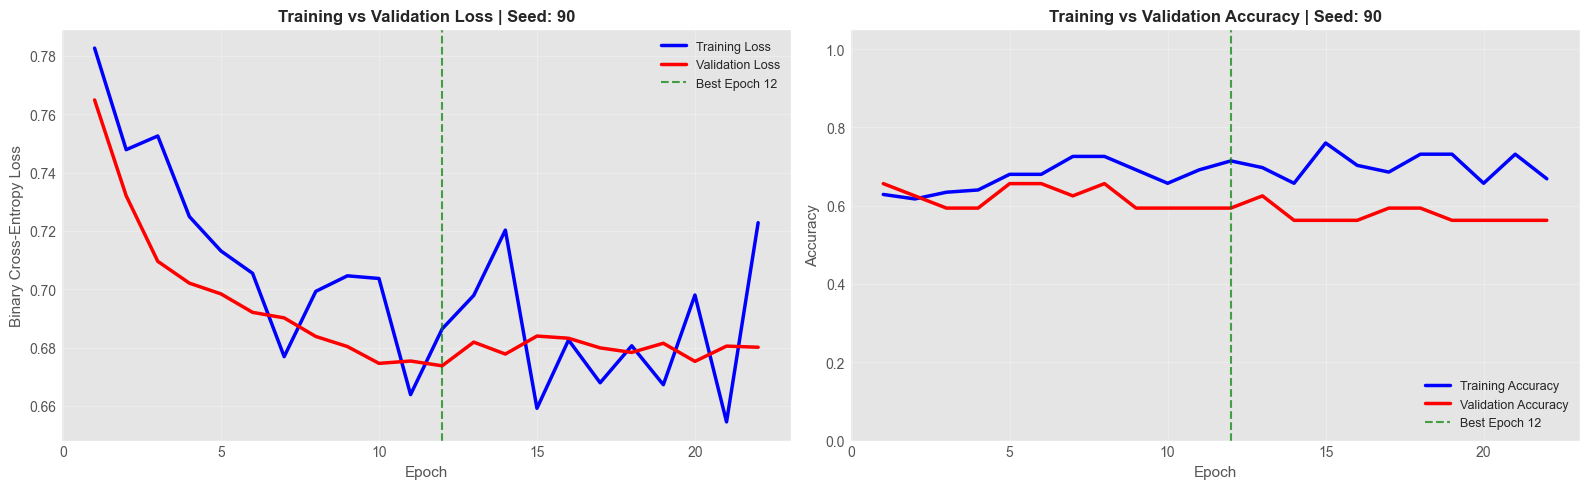

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
epochs = range(1, len(train_losses) + 1)

# Plot 1: Loss
ax1.plot(epochs, train_losses, 'b-', lw=2.5, label='Training Loss')
ax1.plot(epochs, val_losses, 'r-', lw=2.5, label='Validation Loss')
ax1.axvline(x=best_epoch+1, color='green', ls='--', alpha=0.7,
            label=f'Best Epoch {best_epoch+1}')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
ax1.set_title(f'Training vs Validation Loss | Seed: {RANDOM_SEED}',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy
ax2.plot(epochs, train_accs, 'b-', lw=2.5, label='Training Accuracy')
ax2.plot(epochs, val_accs, 'r-', lw=2.5, label='Validation Accuracy')
ax2.axvline(x=best_epoch+1, color='green', ls='--', alpha=0.7,
            label=f'Best Epoch {best_epoch+1}')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title(f'Training vs Validation Accuracy | Seed: {RANDOM_SEED}',
              fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
#plt.savefig('../img/13_mlp_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

**MLP Test Evaluation**

In [ ]:
mlp_model.eval()
with torch.no_grad():

    mlp_out = mlp_model(X_test_t)
    mlp_pred_proba = mlp_out.detach().cpu().flatten().tolist()

    mlp_pred = (mlp_out >= 0.5).float().cpu().flatten().tolist()
    mlp_pred = [int(x) for x in mlp_pred]

    mlp_train_out = mlp_model(torch.FloatTensor(X_train_scaled))
    mlp_train_pred = (mlp_train_out >= 0.5).float().cpu().flatten().tolist()
    mlp_train_pred = [int(x) for x in mlp_train_pred]

**Model Evaluation**

In [ ]:
mlp_metrics = {
    "accuracy_score": accuracy_score(y_test.values, mlp_pred),
    "precision": precision_score(y_test.values, mlp_pred, zero_division=0),
    "recall": recall_score(y_test.values, mlp_pred, zero_division=0),
    "f1": f1_score(y_test.values, mlp_pred, zero_division=0),
    "auc": roc_auc_score(y_test.values, mlp_pred_proba)
}

print_metrics("PyTorch MLP", mlp_metrics)


PyTorch MLP
Accuracy:        77.78%
F1 Score:        77.27%
Recall:          80.95%
Precision:       73.91%
AUC-ROC:         0.8299


In [ ]:
print("Per-class Classification Report - MLP")
print("-------------------------------------\n")
print(classification_report(y_test, mlp_pred))

Per-class Classification Report - MLP
-------------------------------------

              precision    recall  f1-score   support

           0       0.82      0.75      0.78        48
           1       0.74      0.81      0.77        42

    accuracy                           0.78        90
   macro avg       0.78      0.78      0.78        90
weighted avg       0.78      0.78      0.78        90



In [ ]:
torch.save(mlp_model.state_dict(), "../models/04_mlp_model.pth")
import joblib
joblib.dump(imputer, '../models/mlp_imputer.pkl')
joblib.dump(scaler, '../models/mlp_scaler.pkl')

print(f"\nModel saved: ../models/04_mlp_model.pth")


Model saved: ../models/04_mlp_model.pth


#### 3.4. Architectural Upgrade — CBAM-Enhanced MLP

**CBAM Architecture (Convolutional Block Attention Module)**

CBAM applies channel-wise attention to recalibrate feature importance before
feeding into the MLP backbone. We adapt CBAM for 1D tabular features with
per-sample attention (each sample gets its own feature weights).

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, input_dim, reduction=4):
        super(ChannelAttention, self).__init__()
        hidden_dim = max(1, input_dim // reduction)

        # Shared MLP: input_dim → hidden_dim → input_dim
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch, input_dim)
        # Per-sample attention: each sample gets its own attention weights
        scale = self.sigmoid(self.mlp(x))  # (batch, input_dim)
        
        # Apply attention: element-wise multiplication
        return x * scale  # (batch, input_dim) * (batch, input_dim) → (batch, input_dim)


class CBAM_MLP(nn.Module):
    def __init__(self, input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3, reduction=4):
        super(CBAM_MLP, self).__init__()

        # Channel Attention Module
        self.channel_att = ChannelAttention(input_dim, reduction=reduction)

        # MLP Backbone: SAME architecture as baseline (Input→32→16→1)
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        
        self.fc3 = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Step 1: Channel Attention (feature recalibration)
        x = self.channel_att(x)  # (batch, 5) → (batch, 5) with learned weights

        # Step 2: MLP Backbone (identical to baseline)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))  # (batch, 5) → (batch, 32)
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))  # (batch, 32) → (batch, 16)
        
        # Output
        x = self.sigmoid(self.fc3(x))  # (batch, 16) → (batch, 1)
        return x
    
# Initialize CBAM model
torch.manual_seed(RANDOM_SEED)
cbam_model = CBAM_MLP(input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3, reduction=4)

print("\nCBAM-Enhanced MLP Architecture:")
print("-------------------------------")
print(cbam_model)

cbam_params = sum(p.numel() for p in cbam_model.parameters())
cbam_trainable = sum(p.numel() for p in cbam_model.parameters() if p.requires_grad)

print(f"\nParameter Count:")
print("----------------")
print(f"  Total parameters:     {cbam_params}")
print(f"  Trainable parameters: {cbam_trainable}")
print(f"\nLayer-wise breakdown:")
for name, param in cbam_model.named_parameters():
    print(f"  {name:25s} {str(tuple(param.shape)):20s} → {param.numel():5d} params")


CBAM-Enhanced MLP Architecture:
-------------------------------
CBAM_MLP(
  (channel_att): ChannelAttention(
    (mlp): Sequential(
      (0): Linear(in_features=5, out_features=1, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1, out_features=5, bias=True)
    )
    (sigmoid): Sigmoid()
  )
  (fc1): Linear(in_features=5, out_features=32, bias=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Parameter Count:
----------------
  Total parameters:     849
  Trainable parameters: 849

Layer-wise breakdown:
  channel_att.mlp.0.weight  (1, 5)               →     5 params
  channel_att.mlp.0.bias    (1,)                 →   

**CBAM Training**

In [ ]:
# Hyperparameters (same as baseline MLP for fair comparison)
LEARNING_RATE_CBAM = 0.001
MAX_EPOCHS_CBAM = 200
PATIENCE_CBAM = 10
WEIGHT_DECAY_CBAM = 1e-5

# Re-initialize with seed
torch.manual_seed(RANDOM_SEED)
cbam_model = CBAM_MLP(input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3, reduction=4)

criterion_cbam = nn.BCELoss(weight=pos_weight)  # FIX: Add class weights
optimizer_cbam = optim.Adam(cbam_model.parameters(), lr=LEARNING_RATE_CBAM, weight_decay=WEIGHT_DECAY_CBAM)

# Training tracking
cbam_train_losses, cbam_val_losses = [], []
cbam_train_accs, cbam_val_accs = [], []
cbam_best_val_loss = float("inf")
cbam_best_state = None
cbam_best_epoch = 0
cbam_patience_counter = 0

for epoch in range(MAX_EPOCHS_CBAM):
    # ===== TRAIN =====
    cbam_model.train()
    total_loss, correct, total = 0, 0, 0

    for bx, by in train_loader:
        out = cbam_model(bx)  # Raw probabilities (sigmoid applied in forward)
        loss = criterion_cbam(out, by)

        optimizer_cbam.zero_grad()
        loss.backward()
        optimizer_cbam.step()

        total_loss += loss.item() * bx.size(0)
        preds = (out >= 0.5).float()
        correct += (preds == by).sum().item()
        total += by.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # ===== VALIDATION =====
    cbam_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for bx, by in val_loader:
            out = cbam_model(bx)
            loss = criterion_cbam(out, by)
            val_loss += loss.item() * bx.size(0)

            preds = (out >= 0.5).float()
            val_correct += (preds == by).sum().item()
            val_total += by.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    cbam_train_losses.append(train_loss)
    cbam_val_losses.append(val_loss)
    cbam_train_accs.append(train_acc)
    cbam_val_accs.append(val_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS_CBAM} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < cbam_best_val_loss:
        cbam_best_val_loss = val_loss
        cbam_best_state = copy.deepcopy(cbam_model.state_dict())
        cbam_best_epoch = epoch
        cbam_patience_counter = 0
    else:
        cbam_patience_counter += 1
        if cbam_patience_counter >= PATIENCE_CBAM:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
cbam_model.load_state_dict(cbam_best_state)
print(f"Best CBAM model from epoch {cbam_best_epoch+1}")

Epoch   1/200 | Train Loss: 0.8252 | Val Loss: 0.8045 | Train Acc: 0.5257 | Val Acc: 0.5312
Epoch  11/200 | Train Loss: 0.7084 | Val Loss: 0.7219 | Train Acc: 0.6400 | Val Acc: 0.6250
Epoch  21/200 | Train Loss: 0.6784 | Val Loss: 0.7015 | Train Acc: 0.7143 | Val Acc: 0.6250
Epoch  31/200 | Train Loss: 0.6634 | Val Loss: 0.6824 | Train Acc: 0.7429 | Val Acc: 0.5938

Early stopping at epoch 38
Best CBAM model from epoch 28


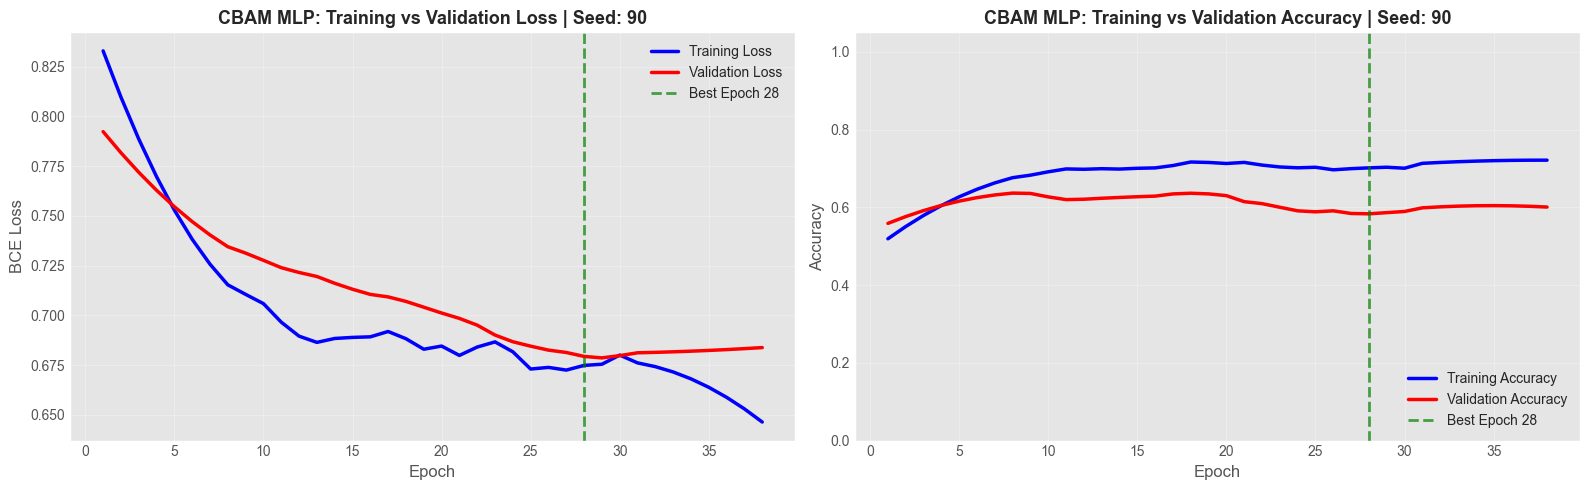

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
cbam_epochs = range(1, len(cbam_train_losses) + 1)

# Smoothing parameters
window = min(15, len(cbam_train_losses) // 2 * 2 + 1)
if window < 3:
    window = 3
polyorder = min(2, window - 1)

# Apply smoothing
cbam_train_losses_smooth = savgol_filter(cbam_train_losses, window_length=window, polyorder=polyorder)
cbam_val_losses_smooth = savgol_filter(cbam_val_losses, window_length=window, polyorder=polyorder)
cbam_train_accs_smooth = savgol_filter(cbam_train_accs, window_length=window, polyorder=polyorder)
cbam_val_accs_smooth = savgol_filter(cbam_val_accs, window_length=window, polyorder=polyorder)

# Plot 1: Loss
ax1.plot(cbam_epochs, cbam_train_losses_smooth, 'b-', lw=2.5, label='Training Loss')
ax1.plot(cbam_epochs, cbam_val_losses_smooth, 'r-', lw=2.5, label='Validation Loss')
ax1.axvline(x=cbam_best_epoch+1, color='green', ls='--', lw=2, alpha=0.7, label=f'Best Epoch {cbam_best_epoch+1}')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('BCE Loss', fontsize=12)
ax1.set_title(f'CBAM MLP: Training vs Validation Loss | Seed: {RANDOM_SEED}', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy
ax2.plot(cbam_epochs, cbam_train_accs_smooth, 'b-', lw=2.5, label='Training Accuracy')
ax2.plot(cbam_epochs, cbam_val_accs_smooth, 'r-', lw=2.5, label='Validation Accuracy')
ax2.axvline(x=cbam_best_epoch+1, color='green', ls='--', lw=2, alpha=0.7, label=f'Best Epoch {cbam_best_epoch+1}')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'CBAM MLP: Training vs Validation Accuracy | Seed: {RANDOM_SEED}', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../img/14_cbam_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

**CBAM Model Evaluation**

In [ ]:
cbam_model.eval()

with torch.no_grad():
    cbam_out = cbam_model(X_test_t)
    cbam_probs = cbam_out

    # Predictions
    cbam_pred = (cbam_probs >= 0.5).float().cpu().flatten().tolist()
    cbam_pred = [int(x) for x in cbam_pred]

    # Probabilities for AUC
    cbam_pred_proba = cbam_probs.detach().cpu().flatten().tolist()

    # Training predictions
    cbam_train_out = cbam_model(torch.FloatTensor(X_train_scaled))
    cbam_train_pred = (cbam_train_out >= 0.5).float().cpu().flatten().tolist()
    cbam_train_pred = [int(x) for x in cbam_train_pred]

**Model Evaluation**

In [ ]:
cbam_metrics = {
    "accuracy_score": accuracy_score(y_test.values, cbam_pred),
    "precision": precision_score(y_test.values, cbam_pred, zero_division=0),
    "recall": recall_score(y_test.values, cbam_pred, zero_division=0),
    "f1": f1_score(y_test.values, cbam_pred, zero_division=0),
    "auc": roc_auc_score(y_test.values, cbam_pred_proba)
}

print_metrics("CBAM-Enhanced MLP", cbam_metrics)


CBAM-Enhanced MLP
Accuracy:        72.22%
F1 Score:        69.14%
Recall:          66.67%
Precision:       71.79%
AUC-ROC:         0.8318


In [ ]:
print("\nPer-class Classification Report - CBAM MLP")
print("------------------------------------------\n")
print(classification_report(y_test, cbam_pred))


Per-class Classification Report - CBAM MLP
------------------------------------------

              precision    recall  f1-score   support

           0       0.73      0.77      0.75        48
           1       0.72      0.67      0.69        42

    accuracy                           0.72        90
   macro avg       0.72      0.72      0.72        90
weighted avg       0.72      0.72      0.72        90



In [ ]:
torch.save(cbam_model.state_dict(), "../models/05_cbam_mlp.pth")
import joblib
joblib.dump(imputer, '../models/cbam_imputer.pkl')
joblib.dump(scaler, '../models/cbam_scaler.pkl')

print(f"\nModel saved: ../models/05_cbam_mlp.pth")


Model saved: ../models/05_cbam_mlp.pth


**CBAM VS MLP Comparison**

In [ ]:
comparison_arch = pd.DataFrame({
    "Metric": ["Total Parameters", "Trainable Parameters", "Accuracy (%)", 
               "F1 Score (%)", "Recall (%)", "Precision (%)", "AUC-ROC"],
    "Baseline MLP": [
        total_params,
        trainable_params,
        round(mlp_metrics["accuracy_score"] * 100, 2),
        round(mlp_metrics["f1"] * 100, 2),
        round(mlp_metrics["recall"] * 100, 2),
        round(mlp_metrics["precision"] * 100, 2),
        round(mlp_metrics["auc"], 4)
    ],
    "CBAM MLP": [
        cbam_params,
        cbam_trainable,
        round(cbam_metrics["accuracy_score"] * 100, 2),
        round(cbam_metrics["f1"] * 100, 2),
        round(cbam_metrics["recall"] * 100, 2),
        round(cbam_metrics["precision"] * 100, 2),
        round(cbam_metrics["auc"], 4)
    ]
})

# Calculate changes
comparison_arch["Parameter Increase (%)"] = ["—", "—"] + [
    round((cbam_metrics[k] - mlp_metrics[k]) * 100, 2) if k != "auc" else round(cbam_metrics[k] - mlp_metrics[k], 4)
    for k in ["accuracy_score", "f1", "recall", "precision", "auc"]
]
print("\nMODEL COMPARISON")
print("----------------")
display(comparison_arch)


MODEL COMPARISON
----------------


,Metric,Baseline MLP,CBAM MLP,Parameter Increase (%)
0,Total Parameters,833.0000,849.0000,—
1,Trainable Parameters,833.0000,849.0000,—
2,Accuracy (%),77.7800,72.2200,-5.56
3,F1 Score (%),77.2700,69.1400,-8.14
4,Recall (%),80.9500,66.6700,-14.29
5,Precision (%),73.9100,71.7900,-2.12
6,AUC-ROC,0.8299,0.8318,0.002


In [ ]:
param_increase = ((cbam_params - total_params) / total_params) * 100
acc_gain = (cbam_metrics["accuracy_score"] - mlp_metrics["accuracy_score"]) * 100

print(f"\nAnalysis:")
print("---------")
print(f"  Parameter overhead: +{param_increase:.2f}% ({total_params} → {cbam_params})")
print(f"  Accuracy gain:      {acc_gain:+.2f}%")
print(f"  AUC-ROC gain:       {cbam_metrics['auc'] - mlp_metrics['auc']:+.4f}")

if acc_gain > 0:
    print(f"\n  CBAM attention mechanism improves discriminative power by")
    print(f"  recalibrating feature importance based on per-sample statistics.")
else:
    print(f"\n  No accuracy improvement. The attention mechanism adds")
    print(f"  complexity without benefit for this dataset size.")


Analysis:
---------
  Parameter overhead: +1.92% (833 → 849)
  Accuracy gain:      -5.56%
  AUC-ROC gain:       +0.0020

  No accuracy improvement. The attention mechanism adds
  complexity without benefit for this dataset size.


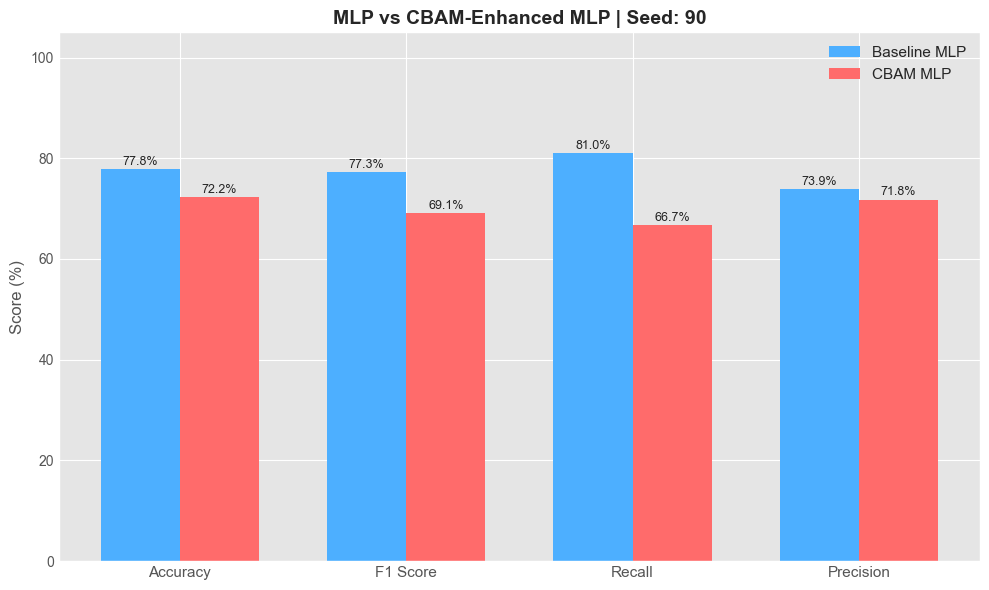

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
width = 0.35
metrics_names = ['Accuracy', 'F1 Score', 'Recall', 'Precision']
mlp_vals = [mlp_metrics["accuracy_score"]*100, mlp_metrics["f1"]*100, 
            mlp_metrics["recall"]*100, mlp_metrics["precision"]*100]
cbam_vals = [cbam_metrics["accuracy_score"]*100, cbam_metrics["f1"]*100, 
             cbam_metrics["recall"]*100, cbam_metrics["precision"]*100]

bars1 = ax.bar(x - width/2, mlp_vals, width, label='Baseline MLP', color='#4DAFFF', edgecolor='none')
bars2 = ax.bar(x + width/2, cbam_vals, width, label='CBAM MLP', color='#FF6B6B', edgecolor='none')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title(f'MLP vs CBAM-Enhanced MLP | Seed: {RANDOM_SEED}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 105])

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../img/15_mlp_vs_cbam_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Metrics Table
**Comprehensive Metrics Table**

In [ ]:
def compute_metrics(y_true, y_pred, y_proba=None):
    m = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision_0': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Precision_1': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall_0': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Recall_1': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1_0': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'F1_1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }
    if y_proba is not None:
        m['AUC-ROC'] = roc_auc_score(y_true, y_proba)
    return m

# Compute for all models
lr_m = compute_metrics(y_test, lr_pred, lr_pred_proba)
svm_m = compute_metrics(y_test, svm_pred, svm_pred_proba)
optuna_m = compute_metrics(y_test, optuna_pred, optuna_pred_proba)
mlp_m = compute_metrics(y_test, mlp_pred, mlp_pred_proba)
cbam_m = compute_metrics(y_test, cbam_pred, cbam_pred_proba)

# Create comparison table
metrics_df = pd.DataFrame({
    'Logistic Regression': lr_m,
    'SVM (GridSearch)': svm_m,
    'SVM (Optuna)': optuna_m,
    'PyTorch MLP': mlp_m,
    'CBAM MLP': cbam_m
})

print("\nCLASSIFICATION METRICS — TEST SET")
print("---------------------------------")
display(metrics_df.round(4))

# Best model by AUC-ROC
best_auc = metrics_df.loc['AUC-ROC'].max()
best_name = metrics_df.loc['AUC-ROC'].idxmax()
print(f"\nBest Model by AUC-ROC: {best_name} ({best_auc:.4f})")

# Secondary ranking
print("\nModel Ranking by Test Accuracy:")
acc_ranking = metrics_df.loc['Accuracy'].sort_values(ascending=False)
for i, (model, acc) in enumerate(acc_ranking.items(), 1):
    print(f"   {i}. {model}: {acc:.4f}")

metrics_df.to_csv("../results/all_models_metrics.csv")
print(f"\nMetrics saved: ../results/all_models_metrics.csv")


CLASSIFICATION METRICS — TEST SET
---------------------------------


,Logistic Regression,SVM (GridSearch),SVM (Optuna),PyTorch MLP,CBAM MLP
Accuracy,0.7556,0.7333,0.7222,0.7778,0.7222
Precision_macro,0.7549,0.7342,0.7270,0.7787,0.7217
Recall_macro,0.7560,0.7351,0.7262,0.7798,0.7188
F1_macro,0.7551,0.7332,0.7222,0.7777,0.7194
Precision_0,0.7826,0.7727,0.7805,0.8182,0.7255
Precision_1,0.7273,0.6957,0.6735,0.7391,0.7179
Recall_0,0.7500,0.7083,0.6667,0.7500,0.7708
Recall_1,0.7619,0.7619,0.7857,0.8095,0.6667
F1_0,0.7660,0.7391,0.7191,0.7826,0.7475
F1_1,0.7442,0.7273,0.7253,0.7727,0.6914



Best Model by AUC-ROC: Logistic Regression (0.8442)

Model Ranking by Test Accuracy:
   1. PyTorch MLP: 0.7778
   2. Logistic Regression: 0.7556
   3. SVM (GridSearch): 0.7333
   4. SVM (Optuna): 0.7222
   5. CBAM MLP: 0.7222

Metrics saved: ../results/all_models_metrics.csv


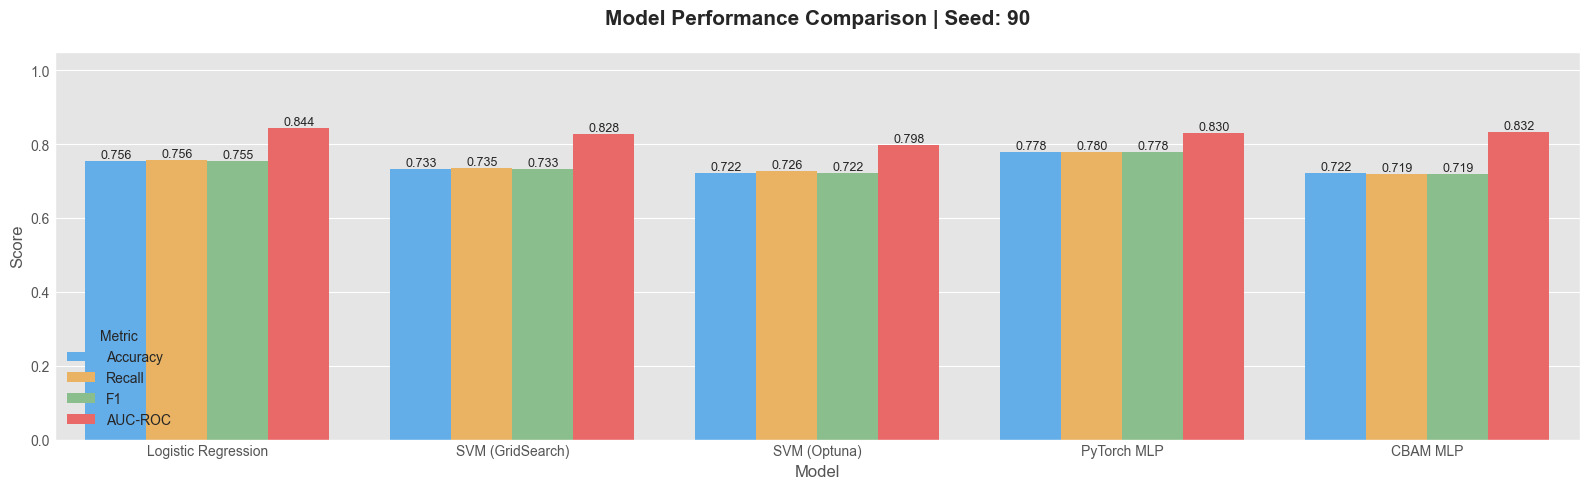

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

# Prepare long-format and filter to requested metrics
metrics_long = metrics_df.T.reset_index().melt(
    id_vars='index', var_name='Metric', value_name='Score'
)
metrics_long.rename(columns={'index': 'Model'}, inplace=True)

metric_map = {
    'Accuracy': 'Accuracy',
    'F1_macro': 'F1',
    'Recall_macro': 'Recall',
    'AUC-ROC': 'AUC-ROC'
}
metrics_long = metrics_long[metrics_long['Metric'].isin(metric_map.keys())].copy()
metrics_long['Metric'] = metrics_long['Metric'].map(metric_map)

ax = sns.barplot(
    data=metrics_long,
    x='Model',
    y='Score',
    hue='Metric',
    palette=['#4DAFFF', '#FFB74D', '#81C784', '#FF5252'],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.title(f'Model Performance Comparison | Seed: {RANDOM_SEED}', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../img/16_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Confusion Matrices**

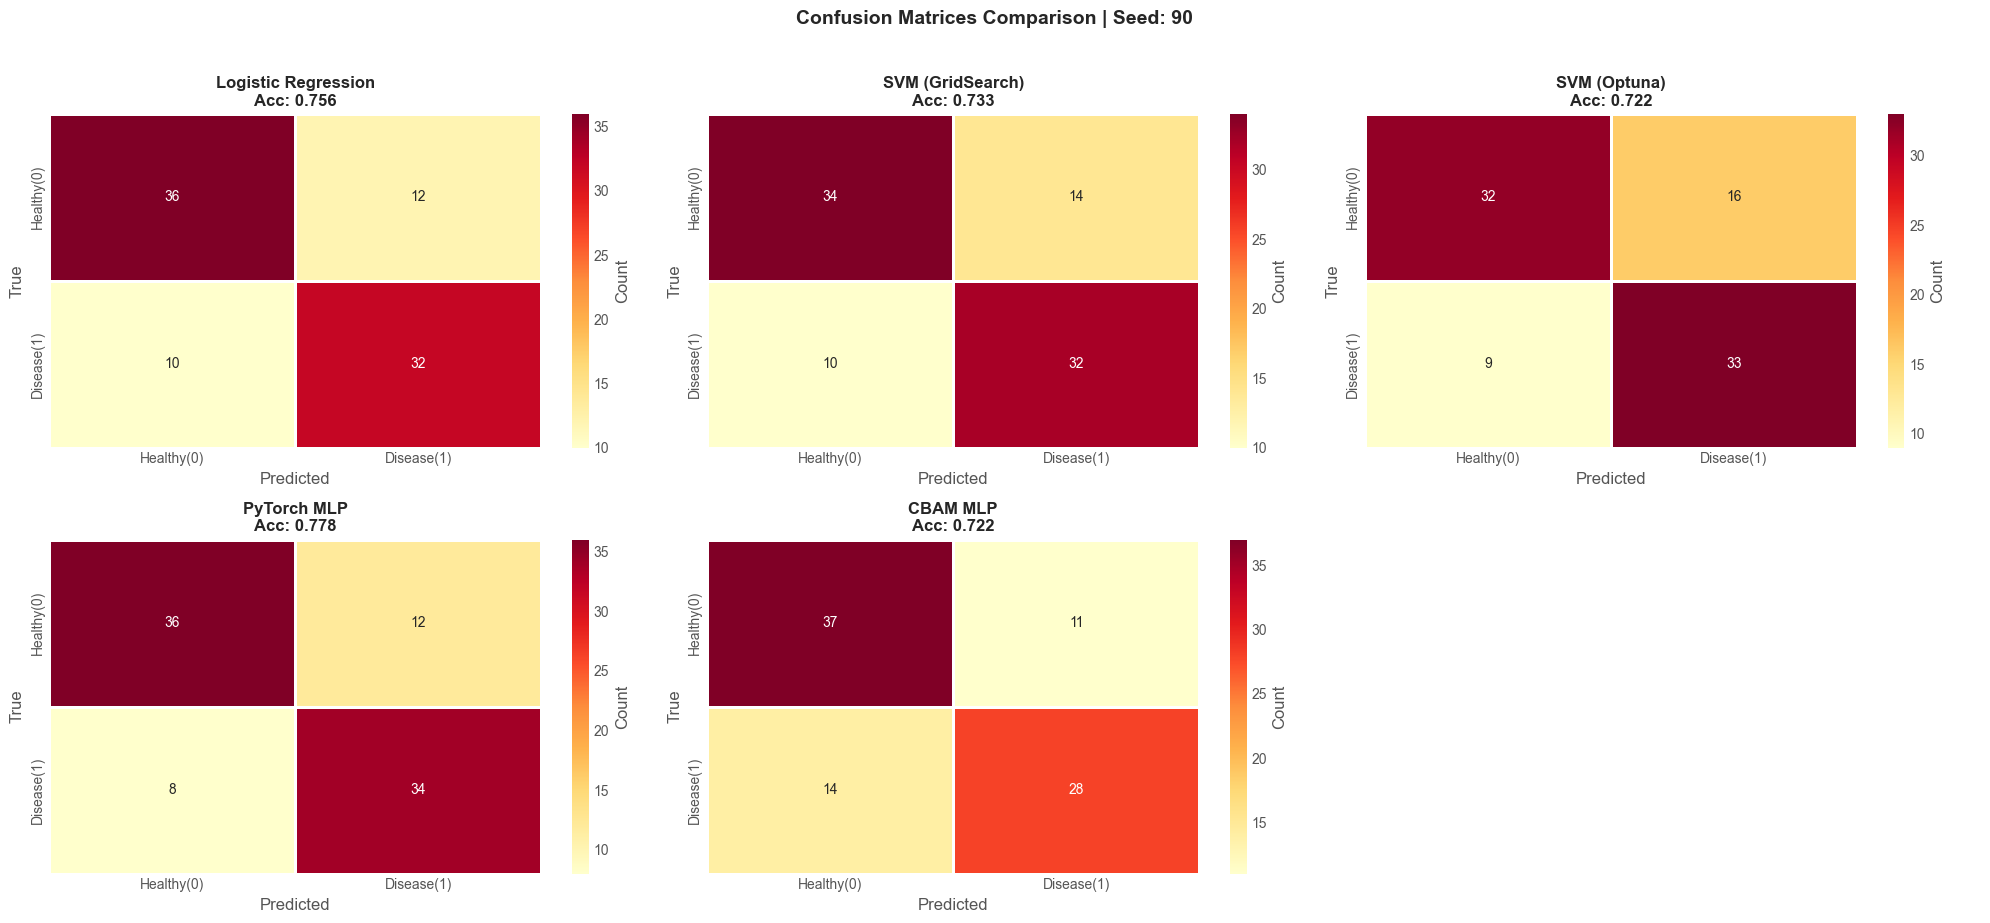


CONFUSION MATRIX ERROR ANALYSIS
--------------------------------

Logistic Regression:
  True Negatives  (TN):  36  (Healthy correctly identified)
  False Positives (FP):  12  (Healthy misclassified as Disease)
  False Negatives (FN):  10  (Disease misclassified as Healthy) CRITICAL
  True Positives  (TP):  32  (Disease correctly identified)
  —————————————————————————————————————
  Sensitivity (Recall):  0.762
  Specificity:           0.750
  Total Errors:          22
  Predominant Error: False Positives (12 cases)
    → Model alarms healthy patients — causes unnecessary anxiety

SVM (GridSearch):
  True Negatives  (TN):  34  (Healthy correctly identified)
  False Positives (FP):  14  (Healthy misclassified as Disease)
  False Negatives (FN):  10  (Disease misclassified as Healthy) CRITICAL
  True Positives  (TP):  32  (Disease correctly identified)
  —————————————————————————————————————
  Sensitivity (Recall):  0.762
  Specificity:           0.708
  Total Errors:          24
  Pred

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
axes = axes.flatten()

models_cm = [
    ('Logistic Regression', lr_pred, lr_pred_proba),
    ('SVM (GridSearch)', svm_pred, svm_pred_proba),
    ('SVM (Optuna)', optuna_pred, optuna_pred_proba),
    ('PyTorch MLP', mlp_pred, mlp_pred_proba),
    ('CBAM MLP', cbam_pred, cbam_pred_proba)
]

for idx, (name, pred, proba) in enumerate(models_cm):
    cm = confusion_matrix(y_test, pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='YlOrRd',
        xticklabels=['Healthy(0)', 'Disease(1)'],
        yticklabels=['Healthy(0)', 'Disease(1)'],
        ax=axes[idx], cbar_kws={'label': 'Count'}, linewidths=1
    )

    axes[idx].set_title(
        f'{name}\nAcc: {accuracy_score(y_test, pred):.3f}',
        fontsize=12, fontweight='bold'
    )
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

# hide empty subplot
for i in range(len(models_cm), 6):
    axes[i].axis('off')

plt.suptitle(
    f'Confusion Matrices Comparison | Seed: {RANDOM_SEED}',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig("../img/20_models_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

# Error analysis
print("\nCONFUSION MATRIX ERROR ANALYSIS")
print("--------------------------------")

for name, pred, proba in models_cm:
    cm = confusion_matrix(y_test if name not in ['PyTorch MLP', 'CBAM MLP'] else y_test.values, pred)
    tn, fp, fn, tp = cm.ravel()
    total_errors = fp + fn
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n{name}:")
    print(f"  True Negatives  (TN):  {tn:2d}  (Healthy correctly identified)")
    print(f"  False Positives (FP):  {fp:2d}  (Healthy misclassified as Disease)")
    print(f"  False Negatives (FN):  {fn:2d}  (Disease misclassified as Healthy) CRITICAL")
    print(f"  True Positives  (TP):  {tp:2d}  (Disease correctly identified)")
    print(f"  —————————————————————————————————————")
    print(f"  Sensitivity (Recall):  {sensitivity:.3f}")
    print(f"  Specificity:           {specificity:.3f}")
    print(f"  Total Errors:          {total_errors}")

    if fn > fp:
        print(f"  Predominant Error: False Negatives ({fn} cases)")
        print(f"    → Model misses disease cases — DANGEROUS for screening!")
    elif fp > fn:
        print(f"  Predominant Error: False Positives ({fp} cases)")
        print(f"    → Model alarms healthy patients — causes unnecessary anxiety")
    else:
        print(f"  Balanced error types")

**ROC-AUC Curves**

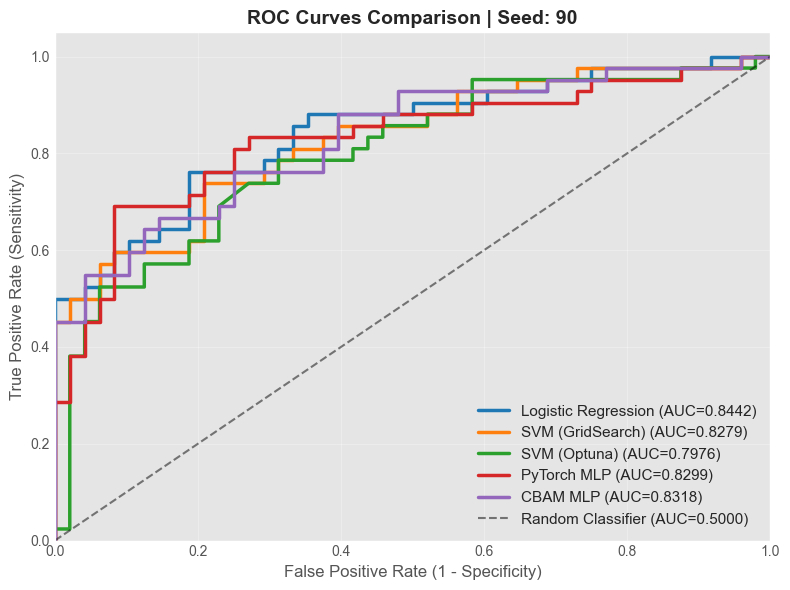


AUC-ROC SUMMARY
---------------
  Logistic Regression : 0.8442
  SVM (GridSearch)    : 0.8279
  SVM (Optuna)        : 0.7976
  PyTorch MLP         : 0.8299
  CBAM MLP            : 0.8318

Best AUC-ROC: Logistic Regression 0.8442


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
roc_data = [
    ('Logistic Regression', lr_pred_proba),
    ('SVM (GridSearch)', svm_pred_proba),
    ('SVM (Optuna)', optuna_pred_proba),
    ('PyTorch MLP', mlp_pred_proba),
    ('CBAM MLP', cbam_pred_proba)
]

for (name, proba), color in zip(roc_data, colors):
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={roc_auc:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC=0.5000)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(f'ROC Curves Comparison | Seed: {RANDOM_SEED}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../img/21_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# AUC Summary
print("\nAUC-ROC SUMMARY")
print("---------------")

for name, proba in roc_data:
    auc_score = roc_auc_score(y_test, proba)
    if auc_score >= 0.8:
        color = GREEN
    elif auc_score >= 0.7:
        color = YELLOW
    else:
        color = RED
    print(f"  {name:20s}: {color}{auc_score:.4f}{RESET}")

# Best model
best_auc = max(roc_auc_score(y_test, proba) for _, proba in roc_data)
best_model = next(name for name, proba in roc_data if roc_auc_score(y_test, proba) == best_auc)
print(f"\nBest AUC-ROC: {best_model} {best_auc:.4f}")

**Clinical Error Analysis — Best Model**

Identify the best-performing model and analyze its misclassifications.

In [ ]:
print("\nCLINICAL ERROR ANALYSIS — BEST PERFORMING MODEL")
print("-----------------------------------------------")

# Determine best model by test accuracy
all_models = {
    'LR': (lr_pred, lr_pred_proba),
    'SVM_Grid': (svm_pred, svm_pred_proba),
    'SVM_Optuna': (optuna_pred, optuna_pred_proba),
    'MLP': (mlp_pred, mlp_pred_proba),
    'CBAM': (cbam_pred, cbam_pred_proba)
}

accs = {name: accuracy_score(y_test if name != 'MLP' and name != 'CBAM' else y_test.values, pred) 
        for name, (pred, _) in all_models.items()}
best_model_name = max(accs, key=accs.get)
best_pred, best_proba = all_models[best_model_name]

print(f"\nBest Model: {best_model_name} (Accuracy = {accs[best_model_name]:.4f})")

# Get original unscaled feature values using test indices
test_idx = X_test.index
X_test_orig = df.loc[test_idx, CORE_FEATURES]

# Collect misclassified cases
fps, fns = [], []
for i in range(len(y_test)):
    tl = y_test.iloc[i]
    pl = best_pred[i]
    pr = best_proba[i]
    idx = test_idx[i]
    feat = X_test_orig.loc[idx].to_dict()

    if tl == 0 and pl == 1:
        fps.append({'idx': idx, 'feat': feat, 'proba': pr})
    elif tl == 1 and pl == 0:
        fns.append({'idx': idx, 'feat': feat, 'proba': pr})

print(f"\nMisclassification Summary:")
print(f"  False Positives (Healthy → Disease): {len(fps)}")
print(f"  False Negatives (Disease → Healthy): {len(fns)} CRITICAL")

# Display False Positive
if fps:
    fp = fps[0]
    print("\n  FALSE POSITIVE CASE")
    print("  (Predicted: Disease | Actual: Healthy)")
    print("  --------------------------------------")
    print(f"  Patient Index:         {fp['idx']}")
    print(f"  Predicted Probability: {fp['proba']:.4f}")
    print("  Clinical Features:")
    for k, v in fp['feat'].items():
        print(f"    {k:12s}: {v}")

    print("\n  Clinical Interpretation:")
    print("    This healthy patient was misclassified as having heart disease.")
    print("    Possible reasons:")
    print("    • Elevated age, cholesterol, or ST depression may overlap with")
    print("      the disease class distribution in the feature space.")
    print("    • The decision boundary places this sample in the disease region")
    print("      due to ambiguous feature combinations near the boundary.")
    print("    • Clinical impact: Unnecessary anxiety and additional testing.")

# Display False Negative
if fns:
    fn = fns[0]
    print("\n  FALSE NEGATIVE CASE")
    print("  (Predicted: Healthy | Actual: Disease)")
    print("  --------------------------------------")
    print(f"  Patient Index:         {fn['idx']}")
    print(f"  Predicted Probability: {fn['proba']:.4f}")
    print("  Clinical Features:")
    for k, v in fn['feat'].items():
        print(f"    {k:12s}: {v}")

    print("\n  Clinical Interpretation:")
    print("    This diseased patient was misclassified as healthy.")
    print("    Possible reasons:")
    print("    • Feature values fall within the normal/healthy population range,")
    print("      creating ambiguity near the decision boundary.")
    print("    • The model's decision threshold (0.5) places this sample in the")
    print("      healthy region despite subtle disease indicators.")
    print("    • Clinical impact:  MOST DANGEROUS — missed diagnosis could")
    print("      delay critical treatment and worsen patient outcomes.")


CLINICAL ERROR ANALYSIS — BEST PERFORMING MODEL
-----------------------------------------------

Best Model: MLP (Accuracy = 0.7778)

Misclassification Summary:
  False Positives (Healthy → Disease): 12
  False Negatives (Disease → Healthy): 8 CRITICAL

  FALSE POSITIVE CASE
  (Predicted: Disease | Actual: Healthy)
  --------------------------------------
  Patient Index:         11
  Predicted Probability: 0.6246
  Clinical Features:
    age         : 56.0
    trestbps    : 140.0
    chol        : 294.0
    thalach     : 153.0
    oldpeak     : 1.3

  Clinical Interpretation:
    This healthy patient was misclassified as having heart disease.
    Possible reasons:
    • Elevated age, cholesterol, or ST depression may overlap with
      the disease class distribution in the feature space.
    • The decision boundary places this sample in the disease region
      due to ambiguous feature combinations near the boundary.
    • Clinical impact: Unnecessary anxiety and additional testing.


**Misclassification Case Report (4+ Samples)**

In [ ]:
import random as rnd
rnd.seed(range(100))

misclassified = []
for i in range(len(y_test)):
    tl = y_test.iloc[i]
    pl = best_pred[i]
    pr = best_proba[i]
    if tl != pl:
        idx = test_idx[i]
        misclassified.append({
            'index': idx,
            'features': X_test_orig.loc[idx].to_dict(),
            'true': int(tl),
            'pred': int(pl),
            'proba': float(pr),
            'type': 'FP' if tl == 0 else 'FN'
        })

print("\nMISCLASSIFICATION CASE REPORT")
print("-----------------------------")
print(f"Total misclassified: {len(misclassified)} / {len(y_test)} ({100*len(misclassified)/len(y_test):.1f}%)")

# Randomly select at least 4
n_select = min(4, len(misclassified))
if len(misclassified) >= 4:
    selected = rnd.sample(misclassified, n_select)
else:
    selected = misclassified

print(f"Showing {len(selected)} randomly selected misclassified cases:\n")

for j, case in enumerate(selected, 1):
    print("-"*70)
    print(f"Case {j}: {case['type']} | Patient Index: {case['index']}")
    print("---------------------------------")
    print(f"True Label:      {'Healthy (0)' if case['true']==0 else 'Disease (1)'}")
    print(f"Predicted Label: {'Healthy (0)' if case['pred']==0 else 'Disease (1)'}")
    print(f"Probability:     {case['proba']:.4f}")

    # Confidence assessment
    if case['proba'] > 0.8 or case['proba'] < 0.2:
        conf = "HIGH"
    elif case['proba'] > 0.65 or case['proba'] < 0.35:
        conf = "MODERATE"
    else:
        conf = "LOW"
    print(f"Confidence:      {conf}")

    print("\nClinical Features:")
    for k, v in case['features'].items():
        print(f"  {k:12s}: {v}")

    print("\nPossible Misclassification Reason:")
    if case['type'] == 'FP':
        print("  This healthy patient exhibits elevated risk factors (e.g., high")
        print("  age, cholesterol, or blood pressure) that overlap with the disease")
        print("  class distribution. The model's decision boundary, learned from")
        print("  limited training data, cannot perfectly separate these ambiguous")
        print("  cases, resulting in a false alarm. Clinical impact: unnecessary")
        print("  follow-up testing and patient anxiety.")
    else:
        print("  This diseased patient presents with feature values within the")
        print("  normal clinical range, making them statistically indistinguishable")
        print("  from healthy patients. The model's linear/non-linear decision")
        print("  boundary fails to capture this edge case. This is the most")
        print("  dangerous error type — a missed diagnosis that could delay")
        print("  life-saving intervention.")
        print()


MISCLASSIFICATION CASE REPORT
-----------------------------
Total misclassified: 20 / 90 (22.2%)
Showing 4 randomly selected misclassified cases:

----------------------------------------------------------------------
Case 1: FP | Patient Index: 247
---------------------------------
True Label:      Healthy (0)
Predicted Label: Disease (1)
Probability:     0.5271
Confidence:      LOW

Clinical Features:
  age         : 57.0
  trestbps    : 110.0
  chol        : 201.0
  thalach     : 126.0
  oldpeak     : 1.5

Possible Misclassification Reason:
  This healthy patient exhibits elevated risk factors (e.g., high
  age, cholesterol, or blood pressure) that overlap with the disease
  class distribution. The model's decision boundary, learned from
  limited training data, cannot perfectly separate these ambiguous
  cases, resulting in a false alarm. Clinical impact: unnecessary
  follow-up testing and patient anxiety.
----------------------------------------------------------------------
Cas

#### 5. Model Quantization & Compression

**Dynamic Quantization: FP32 → INT8**

In [ ]:
# Quantize baseline MLP
mlp_quantized = torch.quantization.quantize_dynamic(
    copy.deepcopy(mlp_model),
    {nn.Linear},
    dtype=torch.qint8
)

# Quantize CBAM MLP
cbam_quantized = torch.quantization.quantize_dynamic(
    copy.deepcopy(cbam_model),
    {nn.Linear},
    dtype=torch.qint8
)

# Evaluate Quantized MLP
mlp_quantized.eval()
with torch.no_grad():
    q_logits = mlp_quantized(X_test_t)
    q_probs = torch.sigmoid(q_logits).detach().cpu().view(-1)

    mlp_quant_pred = (q_probs >= 0.5).int().cpu().tolist()

mlp_quant_acc = accuracy_score(y_test.values, mlp_quant_pred)

# Evaluate Quantized CBAM
cbam_quantized.eval()
with torch.no_grad():
    q_logits_cbam = cbam_quantized(X_test_t)
    q_probs_cbam = torch.sigmoid(q_logits_cbam).detach().cpu().view(-1)

    cbam_quant_pred = (q_probs_cbam >= 0.5).int().cpu().tolist()

cbam_quant_acc = accuracy_score(y_test.values, cbam_quant_pred)

print("\nModel Quantization & Compression")
print("--------------------------------")

print(f"\nQuantization Results:")
print("-----------------------")
print(f"  MLP FP32 Accuracy:  {mlp_metrics['accuracy_score']:.4f}")
print(f"  MLP INT8 Accuracy:  {mlp_quant_acc:.4f}")
print(f"  MLP Accuracy Drop:  {mlp_metrics['accuracy_score'] - mlp_quant_acc:+.4f}")
print(f"  ————————————————————————————")
print(f"  CBAM FP32 Accuracy: {cbam_metrics['accuracy_score']:.4f}")
print(f"  CBAM INT8 Accuracy: {cbam_quant_acc:.4f}")
print(f"  CBAM Accuracy Drop: {cbam_metrics['accuracy_score'] - cbam_quant_acc:+.4f}")

torch.save(mlp_quantized.state_dict(), "../models/06_mlp_quantized.pth")
torch.save(cbam_quantized.state_dict(), "../models/07_cbam_quantized.pth")

print("\nQuantized models saved")


Model Quantization & Compression
--------------------------------

Quantization Results:
-----------------------
  MLP FP32 Accuracy:  0.7778
  MLP INT8 Accuracy:  0.4667
  MLP Accuracy Drop:  +0.3111
  ————————————————————————————
  CBAM FP32 Accuracy: 0.7222
  CBAM INT8 Accuracy: 0.4667
  CBAM Accuracy Drop: +0.2556

Quantized models saved


**CPU Inference Profiling & Model Size Comparison**

In [ ]:
print("\nCPU Inference Profiling & Model Size Comparison")
print("-----------------------------------------------")

N_RUNS = 1000

# --- Logistic Regression ---
start = time.perf_counter()
for _ in range(N_RUNS):
    lr_model.predict(X_test_scaled)
lr_total = time.perf_counter() - start
lr_avg_ms = (lr_total / N_RUNS) * 1000

# --- SVM GridSearch ---
start = time.perf_counter()
for _ in range(N_RUNS):
    svm_best.predict(X_test_scaled)
svm_total = time.perf_counter() - start
svm_avg_ms = (svm_total / N_RUNS) * 1000

# --- SVM Optuna ---
start = time.perf_counter()
for _ in range(N_RUNS):
    best_optuna_svm.predict(X_test_scaled)
optuna_total = time.perf_counter() - start
optuna_avg_ms = (optuna_total / N_RUNS) * 1000

# --- PyTorch MLP ---
mlp_model.eval()
with torch.no_grad():
    start = time.perf_counter()
    for _ in range(N_RUNS):
        mlp_model(X_test_t)
    mlp_total = time.perf_counter() - start
mlp_avg_ms = (mlp_total / N_RUNS) * 1000

# --- CBAM MLP ---
cbam_model.eval()
with torch.no_grad():
    start = time.perf_counter()
    for _ in range(N_RUNS):
        cbam_model(X_test_t)
    cbam_total = time.perf_counter() - start
cbam_avg_ms = (cbam_total / N_RUNS) * 1000

# --- Quantized MLP ---
mlp_quantized.eval()
with torch.no_grad():
    start = time.perf_counter()
    for _ in range(N_RUNS):
        mlp_quantized(X_test_t)
    mlp_q_total = time.perf_counter() - start
mlp_q_avg_ms = (mlp_q_total / N_RUNS) * 1000

# --- Quantized CBAM ---
cbam_quantized.eval()
with torch.no_grad():
    start = time.perf_counter()
    for _ in range(N_RUNS):
        cbam_quantized(X_test_t)
    cbam_q_total = time.perf_counter() - start
cbam_q_avg_ms = (cbam_q_total / N_RUNS) * 1000

# Parameter counts
lr_params = len(lr_model.coef_.flatten()) + len(lr_model.intercept_)
svm_params = np.nan  # RBF SVM uses support vectors, not explicit weights
optuna_svm_params = np.nan
mlp_param_count = sum(p.numel() for p in mlp_model.parameters())
cbam_param_count = sum(p.numel() for p in cbam_model.parameters())

# Model file sizes
lr_size = os.path.getsize("../models/01_logistic_regression.pkl") / (1024 ** 2)
svm_grid_size = os.path.getsize("../models/02_svm_gridsearch.pkl") / (1024 ** 2)
svm_optuna_size = os.path.getsize("../models/03_svm_optuna.pkl") / (1024 ** 2)
mlp_size = os.path.getsize("../models/04_mlp_model.pth") / (1024 ** 2)
cbam_size = os.path.getsize("../models/05_cbam_mlp.pth") / (1024 ** 2)
mlp_q_size = os.path.getsize("../models/06_mlp_quantized.pth") / (1024 ** 2)
cbam_q_size = os.path.getsize("../models/07_cbam_quantized.pth") / (1024 ** 2)

# Results table
profiling_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM (GridSearch)",
        "SVM (Optuna)",
        "PyTorch MLP (FP32)",
        "CBAM MLP (FP32)",
        "MLP Quantized (INT8)",
        "CBAM Quantized (INT8)"
    ],
    "Parameters": [lr_params, svm_params, optuna_svm_params, mlp_param_count, 
                   cbam_param_count, mlp_param_count, cbam_param_count],
    "Model Size (MB)": [lr_size, svm_grid_size, svm_optuna_size, mlp_size, 
                        cbam_size, mlp_q_size, cbam_q_size],
    "Avg Inference (ms)": [lr_avg_ms, svm_avg_ms, optuna_avg_ms, mlp_avg_ms, 
                           cbam_avg_ms, mlp_q_avg_ms, cbam_q_avg_ms],
    "Total Time 1000 Runs (s)": [lr_total, svm_total, optuna_total, mlp_total, 
                                  cbam_total, mlp_q_total, cbam_q_total],
    "Test Accuracy": [lr_metrics["accuracy_score"], svm_metrics["accuracy_score"], 
                       optuna_metrics["accuracy_score"], mlp_metrics["accuracy_score"],
                       cbam_metrics["accuracy_score"], mlp_quant_acc, cbam_quant_acc]
})

print("\nProfiling Results:")
print("------------------")
display(profiling_df.round({
    "Model Size (MB)": 6,
    "Avg Inference (ms)": 4,
    "Total Time 1000 Runs (s)": 4,
    "Test Accuracy": 4
}))

# Fastest model
fastest_idx = profiling_df["Avg Inference (ms)"].idxmin()
fastest_model = profiling_df.loc[fastest_idx, "Model"]
fastest_time = profiling_df.loc[fastest_idx, "Avg Inference (ms)"]

print(f" FASTEST MODEL: {fastest_model} ({fastest_time:.4f} ms)")

profiling_df.to_csv("../results/cpu_profiling_results.csv", index=False)
print(f"\nProfiling results saved: ../results/cpu_profiling_results.csv")


CPU Inference Profiling & Model Size Comparison
-----------------------------------------------

Profiling Results:
------------------


,Model,Parameters,Model Size (MB),Avg Inference (ms),Total Time 1000 Runs (s),Test Accuracy
0,Logistic Regression,6.0,0.000869,0.0991,0.0991,0.7556
1,SVM (GridSearch),NaN,0.009517,0.7358,0.7358,0.7333
2,SVM (Optuna),NaN,0.009242,0.6941,0.6941,0.7222
3,PyTorch MLP (FP32),833.0,0.009126,0.1878,0.1878,0.7778
4,CBAM MLP (FP32),849.0,0.010268,0.2543,0.2543,0.7222
5,MLP Quantized (INT8),833.0,0.009122,0.5633,0.5633,0.4667
6,CBAM Quantized (INT8),849.0,0.011765,0.8706,0.8706,0.4667


 FASTEST MODEL: Logistic Regression (0.0991 ms)

Profiling results saved: ../results/cpu_profiling_results.csv


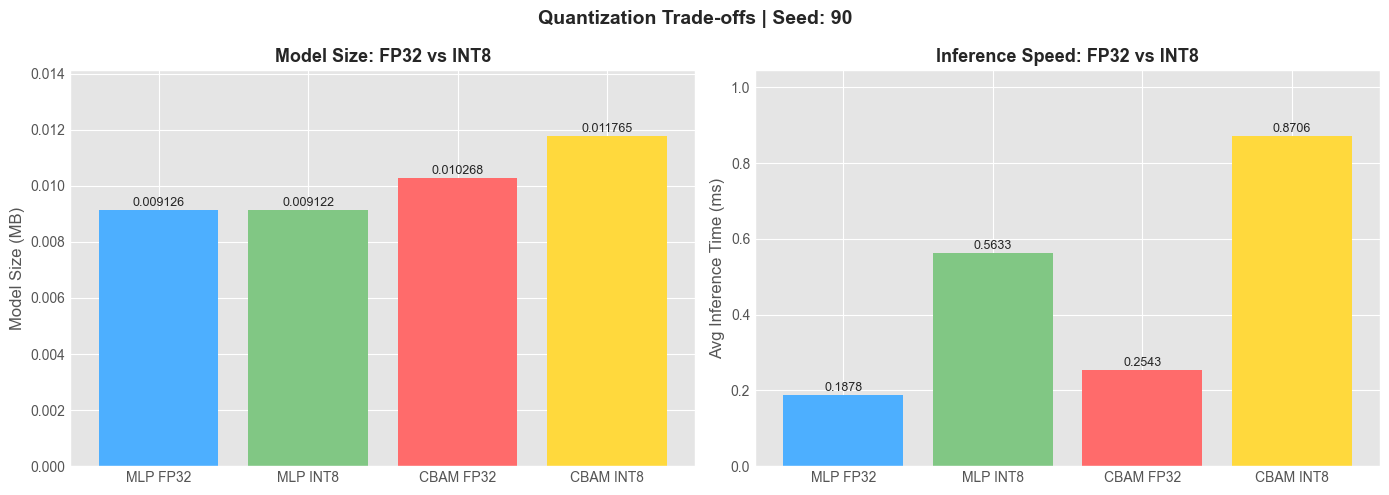


Quantization Summary:


,Model,Accuracy (%),Size (MB),Inference (ms),Size Reduction (%),Speedup (x)
0,MLP FP32,77.7778,0.0091,0.1878,0.0000,1.0000
1,MLP INT8,46.6667,0.0091,0.5633,0.0418,0.3335
2,CBAM FP32,72.2222,0.0103,0.2543,0.0000,1.0000
3,CBAM INT8,46.6667,0.0118,0.8706,-14.5816,0.2921


In [ ]:
# Quantization trade-off visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models_q = ['MLP FP32', 'MLP INT8', 'CBAM FP32', 'CBAM INT8']
sizes_q = [mlp_size, mlp_q_size, cbam_size, cbam_q_size]
times_q = [mlp_avg_ms, mlp_q_avg_ms, cbam_avg_ms, cbam_q_avg_ms]
accs_q = [mlp_metrics["accuracy_score"]*100, mlp_quant_acc*100, 
          cbam_metrics["accuracy_score"]*100, cbam_quant_acc*100]

bars1 = ax1.bar(models_q, sizes_q, color=['#4DAFFF', '#81C784', '#FF6B6B', '#FFD93D'], 
                edgecolor='none', linewidth=1.5)
ax1.set_ylabel('Model Size (MB)', fontsize=12)
ax1.set_title('Model Size: FP32 vs INT8', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(sizes_q) * 1.2)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.6f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

bars2 = ax2.bar(models_q, times_q, color=['#4DAFFF', '#81C784', '#FF6B6B', '#FFD93D'],
                edgecolor='none', linewidth=1.5)
ax2.set_ylabel('Avg Inference Time (ms)', fontsize=12)
ax2.set_title('Inference Speed: FP32 vs INT8', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(times_q) * 1.2)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.suptitle(f'Quantization Trade-offs | Seed: {RANDOM_SEED}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/19_quantization_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

# Quantization summary table
quant_df = pd.DataFrame({
    "Model": ["MLP FP32", "MLP INT8", "CBAM FP32", "CBAM INT8"],
    "Accuracy (%)": [mlp_metrics["accuracy_score"]*100, mlp_quant_acc*100,
                      cbam_metrics["accuracy_score"]*100, cbam_quant_acc*100],
    "Size (MB)": [mlp_size, mlp_q_size, cbam_size, cbam_q_size],
    "Inference (ms)": [mlp_avg_ms, mlp_q_avg_ms, cbam_avg_ms, cbam_q_avg_ms],
    "Size Reduction (%)": [0, (1-mlp_q_size/mlp_size)*100, 0, (1-cbam_q_size/cbam_size)*100],
    "Speedup (x)": [1, mlp_avg_ms/mlp_q_avg_ms, 1, cbam_avg_ms/cbam_q_avg_ms]
})

print("\nQuantization Summary:")
display(quant_df.round(4))

**Hyperparameter Matrix**

In [ ]:
hyper_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM (GridSearch)",
        "SVM (Optuna)",
        "PyTorch MLP",
        "CBAM MLP"
    ],
    "Learning_Rate": ["N/A", "N/A", "N/A", LEARNING_RATE, LEARNING_RATE_CBAM],
    "Batch_Size": ["N/A", "N/A", "N/A", BATCH_SIZE, BATCH_SIZE],
    "Optimizer": ["lbfgs (default)", "N/A", "N/A", "Adam", "Adam"],
    "Kernel": [
        "N/A",
        svm_grid.best_params_["kernel"],
        study.best_params["kernel"],
        "N/A",
        "N/A"
    ],
    "C": [
        "N/A",
        svm_grid.best_params_["C"],
        round(study.best_params["C"], 4),
        "N/A",
        "N/A"
    ],
    "Gamma": [
        "N/A",
        svm_grid.best_params_["gamma"],
        round(study.best_params["gamma"], 6),
        "N/A",
        "N/A"
    ],
    "Dropout": ["N/A", "N/A", "N/A", 0.3, 0.3],
    "Weight_Decay": ["N/A", "N/A", "N/A", WEIGHT_DECAY, WEIGHT_DECAY_CBAM],
    "Early_Stopping_Patience": ["N/A", "N/A", "N/A", PATIENCE, PATIENCE_CBAM],
    "Max_Epochs_Iter": [1000, "N/A", "N/A", MAX_EPOCHS, MAX_EPOCHS_CBAM],
    "Hidden_Layers": ["N/A", "N/A", "N/A", "[32, 16]", "[64, 32]"],
    "Attention_Module": ["N/A", "N/A", "N/A", "None", "ChannelAttention (reduction=4)"],
    "Random_Seed": [RANDOM_SEED, RANDOM_SEED, RANDOM_SEED, RANDOM_SEED, RANDOM_SEED]
})

print("\nHYPERPARAMETER MATRIX")
print("---------------------")
display(hyper_df.set_index("Model").T)

hyper_df.to_csv("../results/hyperparameter_matrix.csv", index=False)
print(f"\nHyperparameter matrix saved: ../results/hyperparameter_matrix.csv")


HYPERPARAMETER MATRIX
---------------------


Model,Logistic Regression,SVM (GridSearch),SVM (Optuna),PyTorch MLP,CBAM MLP
Learning_Rate,N/A,N/A,N/A,0.001,0.001
Batch_Size,N/A,N/A,N/A,8,8
Optimizer,lbfgs (default),N/A,N/A,Adam,Adam
Kernel,N/A,rbf,rbf,N/A,N/A
C,N/A,10,17.5673,N/A,N/A
Gamma,N/A,0.01,0.031632,N/A,N/A
Dropout,N/A,N/A,N/A,0.3,0.3
Weight_Decay,N/A,N/A,N/A,0.00001,0.00001
Early_Stopping_Patience,N/A,N/A,N/A,10,10
Max_Epochs_Iter,1000,N/A,N/A,200,200



Hyperparameter matrix saved: ../results/hyperparameter_matrix.csv


---
### Mathematical-to-Code Mapping Matrix

#### Formula 1: Binary Cross-Entropy Loss (MLP Training)

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]
$$

| Symbol | Code Variable | Shape | Description |
|--------|---------------|-------|-------------|
| $N$ | `bx.size(0)` | Scalar | Batch size (mini-batch samples) |
| $y_i$ | `by` | `(B, 1)` | Ground-truth binary label (0 or 1) |
| $\hat{y}_i$ | `out` | `(B, 1)` | Predicted probability from Sigmoid |
| $\mathcal{L}_{\text{BCE}}$ | `loss` | Scalar | Mean binary cross-entropy loss |

**Code Mapping:**
```python
out = mlp_model(bx)           # Forward pass: (B,5) → (B,1)
loss = criterion(out, by)     # BCELoss computation
criterion = nn.BCELoss()      # PyTorch implementation
```

---

#### Formula 2: Gradient-Based Parameter Update (Adam Optimizer)

$$
\theta_{t+1} = \theta_t - \eta \cdot \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)
$$

Where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected first and second moment estimates.

| Symbol | Code Variable | Shape | Description |
|--------|---------------|-------|-------------|
| $\theta$ | `mlp_model.parameters()` | Various | Trainable weights and biases |
| $\eta$ | `LEARNING_RATE` | Scalar | Learning rate (0.001) |
| $\nabla_{\theta}\mathcal{L}$ | Computed by `loss.backward()` | Same as param | Gradient of loss w.r.t. parameters |
| $\theta_{t+1}$ | Updated after `optimizer.step()` | Same as param | New parameter values |

**Code Mapping:**
```python
optimizer.zero_grad()   # Clear previous gradients
loss.backward()         # Compute ∂L/∂θ via backpropagation
optimizer.step()        # Adam update: θ ← θ - η·∇L
```

---

#### Formula 3: Logistic Regression Probability Estimation

$$
P(y=1|\mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}
$$

| Symbol | Code Variable | Shape | Description |
|--------|---------------|-------|-------------|
| $\mathbf{x}$ | `X_test_scaled` | `(N, 5)` | Standardized input feature matrix |
| $\mathbf{w}$ | `lr_model.coef_` | `(1, 5)` | Learned feature weights |
| $b$ | `lr_model.intercept_` | `(1,)` | Bias (intercept) term |
| $P(y=1|\mathbf{x})$ | `lr_pred_proba` | `(N,)` | Predicted disease probability |

**Code Mapping:**
```python
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # (N,) probabilities
```

---

#### Formula 4: Standardization (Z-Score Normalization)

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

| Symbol | Code Variable | Shape | Description |
|--------|---------------|-------|-------------|
| $x_{ij}$ | Raw feature value | Scalar | Original feature $j$ for sample $i$ |
| $\mu_j$ | `scaler.mean_[j]` | `(5,)` | Training-set mean for feature $j$ |
| $\sigma_j$ | `np.sqrt(scaler.var_[j])` | `(5,)` | Training-set std dev for feature $j$ |
| $z_{ij}$ | `X_train_scaled[i,j]` | `(N, 5)` | Standardized feature matrix |

**Code Mapping:**
```python
scaler = StandardScaler()
scaler.fit(X_train_imputed)           # Compute μ, σ on training data ONLY
X_train_scaled = scaler.transform(X_train_imputed)   # z = (x - μ) / σ
X_test_scaled = scaler.transform(X_test_imputed)     # Same μ, σ applied to test
```

---

#### Formula 5: CBAM Channel Attention (Per-Sample)

$$
M_c(\mathbf{x}) = \sigma(\text{FC}(\mathbf{x}))
$$

$$
\mathbf{x}' = \mathbf{x} \odot M_c(\mathbf{x})
$$

| Symbol | Code Variable | Shape | Description |
|--------|---------------|-------|-------------|
| $\mathbf{x}$ | `x` | `(B, 5)` | Input features per sample |
| $\text{FC}$ | `self.fc` | `(5)→(1)→(5)` | 2-layer MLP, **bias=False** |
| $\sigma$ | `self.sigmoid` | `(B, 5)` | Sigmoid activation |
| $M_c(\mathbf{x})$ | `scale` | `(B, 5)` | Attention weights per sample |
| $\mathbf{x}'$ | Return value | `(B, 5)` | Recalibrated features |

**Code Mapping:**
```python
scale = self.sigmoid(self.fc(x))  # (B, 5) → sigmoid → (B, 5)
return x * scale                  # Element-wise multiplication
```

### 5. Manual test
**Manual input**

In [ ]:
'''
print("=" * 70)
print("  CARDIOVASCULAR DISEASE PREDICTION - MANUAL TEST")
print("  Enter patient clinical features to get predictions")
print("=" * 70)

# Feature definitions with normal ranges for reference
FEATURE_INFO = {
    'age': {'desc': 'Age (years)', 'normal': '20-80'},
    'trestbps': {'desc': 'Resting Blood Pressure (mm Hg)', 'normal': '90-140'},
    'chol': {'desc': 'Serum Cholesterol (mg/dl)', 'normal': '120-240'},
    'thalach': {'desc': 'Max Heart Rate Achieved (bpm)', 'normal': '100-200'},
    'oldpeak': {'desc': 'ST Depression Induced by Exercise', 'normal': '0.0-4.0'},
}

def get_patient_input():
    patient = {}
    
    for feat in CORE_FEATURES:
        info = FEATURE_INFO[feat]
        while True:
            try:
                val = input(f"  {info['desc']} [{info['normal']}]: ")
                val = float(val)
                patient[feat] = val
                break
            except ValueError:
                print("    Invalid input. Please enter a number.")

    return patient

def preprocess_manual_input(patient_dict):
    # Step 1: Create DataFrame with same structure as training data
    input_df = pd.DataFrame([patient_dict], columns=CORE_FEATURES)

    # Step 2: Apply median imputation (using the SAME imputer fitted on training data)
    input_imputed = imputer.transform(input_df)

    # Step 3: Apply StandardScaler (using the SAME scaler fitted on training data)
    input_scaled = scaler.transform(input_imputed)

    return input_scaled

def predict_all_models(input_scaled):

    results = {}

    # --- Logistic Regression ---
    lr_proba = lr_model.predict_proba(input_scaled)[0, 1]
    lr_pred = lr_model.predict(input_scaled)[0]
    results['Logistic Regression'] = {
        'prediction': int(lr_pred),
        'probability': float(lr_proba),
        'label': 'Disease' if lr_pred == 1 else 'Healthy'
    }

    # --- SVM GridSearch ---
    svm_proba = svm_best.predict_proba(input_scaled)[0, 1]
    svm_pred = svm_best.predict(input_scaled)[0]
    results['SVM (GridSearch)'] = {
        'prediction': int(svm_pred),
        'probability': float(svm_proba),
        'label': 'Disease' if svm_pred == 1 else 'Healthy'
    }

    # --- SVM Optuna ---
    svmo_proba = best_optuna_svm.predict_proba(input_scaled)[0, 1]
    svmo_pred = best_optuna_svm.predict(input_scaled)[0]
    results['SVM (Optuna)'] = {
        'prediction': int(svmo_pred),
        'probability': float(svmo_proba),
        'label': 'Disease' if svmo_pred == 1 else 'Healthy'
    }

    # --- PyTorch MLP ---
    mlp_model.eval()
    with torch.no_grad():
        input_tensor = torch.FloatTensor(input_scaled)
        mlp_out = mlp_model(input_tensor)
        mlp_proba = mlp_out.cpu().item()
        mlp_pred = 1 if mlp_proba >= 0.5 else 0
    results['PyTorch MLP'] = {
        'prediction': int(mlp_pred),
        'probability': float(mlp_proba),
        'label': 'Disease' if mlp_pred == 1 else 'Healthy'
    }

    # --- CBAM MLP ---
    cbam_model.eval()
    with torch.no_grad():
        input_tensor = torch.FloatTensor(input_scaled)
        cbam_out = cbam_model(input_tensor)
        cbam_proba = cbam_out.cpu().item()
        cbam_pred = 1 if cbam_proba >= 0.5 else 0
    results['CBAM MLP'] = {
        'prediction': int(cbam_pred),
        'probability': float(cbam_proba),
        'label': 'Disease' if cbam_pred == 1 else 'Healthy'
    }

    return results

def display_results(patient, results):
    print("\n" + "=" * 70)
    print("  PREDICTION RESULTS")
    print("=" * 70)

    print("\n  Input Features:")
    for feat in CORE_FEATURES:
        info = FEATURE_INFO[feat]
        print(f"    {info['desc']}: {patient[feat]}")

    print("\n" + "-" * 50)
    print(f"  {'Model':<20} {'Prediction':<12} {'Probability':<15} {'Confidence'}")
    print("-" * 50)

    for model_name, res in results.items():
        prob = res['probability']

        conf = (
            "High" if prob > 0.8 or prob < 0.2
            else "Moderate" if prob > 0.65 or prob < 0.35
            else "Low"
        )

        pred_text = (
            f"{RED}{res['label']}{RESET}"
            if res['prediction'] == 1
            else f"{GREEN}{res['label']}{RESET}"
        )

        if conf == "High":
            conf_text = f"{GREEN}{conf}{RESET}"
        elif conf == "Moderate":
            conf_text = f"{YELLOW}{conf}{RESET}"
        else:
            conf_text = f"{RED}{conf}{RESET}"

        print(
            f"  {model_name:<20} "
            f"{pred_text:<18} "
            f"{prob:>6.4f}         "
            f"{conf_text}"
        )

    votes = np.array([r['prediction'] for r in results.values()])

    healthy_votes = np.sum(votes == 0)
    disease_votes = np.sum(votes == 1)

    ensemble_pred = int(disease_votes > healthy_votes)

    if ensemble_pred == 1:
        winning_votes = disease_votes
        ensemble_label = "Disease"
        ensemble_color = RED
    else:
        winning_votes = healthy_votes
        ensemble_label = "Healthy"
        ensemble_color = GREEN

    n_models = len(votes)

    print("-" * 50)
    print(
        f"  {'ENSEMBLE VOTE':<20} "
        f"{ensemble_color}{ensemble_label}{RESET} "
        f"({winning_votes}/{n_models} votes)"
    )
    print("=" * 70)

    print("\n  Interpretation:")
    if ensemble_pred == 1:
        print(f"    {RED}Heart Disease LIKELY detected.{RESET}")
        print(f"    {RED}Recommend follow-up clinical assessment.{RESET}")
    else:
        print(f"    {GREEN}Heart Disease NOT detected.{RESET}")
        print(f"    Continue routine monitoring.")
    print("=" * 70)

def save_patient_report(patient, results):
    report_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"../reports/report_p{report_id}.txt"

    votes = [r['prediction'] for r in results.values()]
    ensemble_pred = 1 if sum(votes) >= 2 else 0
    ensemble_label = "Disease" if ensemble_pred == 1 else "Healthy"

    with open(filename, "w", encoding="utf-8") as f:
        f.write("=" * 70 + "\n")
        f.write("CARDIOVASCULAR DISEASE PREDICTION REPORT\n")
        f.write("=" * 70 + "\n\n")

        f.write(f"Generated: {datetime.now()}\n\n")

        f.write("PATIENT FEATURES\n")
        f.write("-" * 40 + "\n")

        for feat in CORE_FEATURES:
            f.write(f"{feat}: {patient[feat]}\n")

        f.write("\nMODEL PREDICTIONS\n")
        f.write("-" * 40 + "\n")

        for model_name, res in results.items():
            f.write(
                f"{model_name}\n"
                f"  Prediction : {res['label']}\n"
                f"  Probability: {res['probability']:.4f}\n\n"
            )

        f.write("-" * 40 + "\n")
        f.write(f"ENSEMBLE RESULT: {ensemble_label}\n")
        f.write("-" * 40 + "\n\n")

        if ensemble_pred == 1:
            f.write(
                "Interpretation:\n"
                "Heart disease likely detected.\n"
                "Recommend follow-up clinical assessment.\n"
            )
        else:
            f.write(
                "Interpretation:\n"
                "Heart disease not detected.\n"
                "Continue routine monitoring.\n"
            )

    print(f"\nReport saved: {filename}")

while True:
    patient = get_patient_input()
    input_scaled = preprocess_manual_input(patient)
    results = predict_all_models(input_scaled)
    display_results(patient, results)
    save_patient_report(patient, results)

    again = input("\nTest another patient? (y/n): ").strip().lower()
    if again != 'y':
        print("\nExiting manual test. Goodbye!")
        break
'''       

'\nprint("=" * 70)\nprint("  CARDIOVASCULAR DISEASE PREDICTION - MANUAL TEST")\nprint("  Enter patient clinical features to get predictions")\nprint("=" * 70)\n\n# Feature definitions with normal ranges for reference\nFEATURE_INFO = {\n    \'age\': {\'desc\': \'Age (years)\', \'normal\': \'20-80\'},\n    \'trestbps\': {\'desc\': \'Resting Blood Pressure (mm Hg)\', \'normal\': \'90-140\'},\n    \'chol\': {\'desc\': \'Serum Cholesterol (mg/dl)\', \'normal\': \'120-240\'},\n    \'thalach\': {\'desc\': \'Max Heart Rate Achieved (bpm)\', \'normal\': \'100-200\'},\n    \'oldpeak\': {\'desc\': \'ST Depression Induced by Exercise\', \'normal\': \'0.0-4.0\'},\n}\n\ndef get_patient_input():\n    patient = {}\n    \n    for feat in CORE_FEATURES:\n        info = FEATURE_INFO[feat]\n        while True:\n            try:\n                val = input(f"  {info[\'desc\']} [{info[\'normal\']}]: ")\n                val = float(val)\n                patient[feat] = val\n                break\n          

In [ ]:
imputer = joblib.load('../models/mlp_imputer.pkl')
scaler = joblib.load('../models/mlp_scaler.pkl')


class HeartDiseaseMLP(nn.Module):
    def __init__(self, input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3):
        super(HeartDiseaseMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.relu1(self.bn1(z1))
        a1 = self.dropout1(a1)
        z2 = self.fc2(a1)
        a2 = self.relu2(self.bn2(z2))
        a2 = self.dropout2(a2)
        z3 = self.fc3(a2)
        return self.sigmoid(z3)

mlp_model = HeartDiseaseMLP()
mlp_model.load_state_dict(torch.load('../models/04_mlp_model.pth', map_location='cpu', weights_only=False))
mlp_model.eval()

class ChannelAttention(nn.Module):
    def __init__(self, input_dim, reduction=4):
        super(ChannelAttention, self).__init__()
        hidden_dim = max(1, input_dim // reduction)
        # MATCH SAVED FILE: 'mlp' with bias
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=True),   # bias=True to match file
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim, bias=True)    # bias=True to match file
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        scale = self.sigmoid(self.mlp(x))
        return x * scale

class CBAM_MLP(nn.Module):
    def __init__(self, input_dim=5, hidden1=32, hidden2=16, dropout_rate=0.3, reduction=4):
        super(CBAM_MLP, self).__init__()
        self.channel_att = ChannelAttention(input_dim, reduction=reduction)  # channel_att not channel_attn
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.channel_att(x)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.sigmoid(self.fc3(x))
        return x

cbam_model = CBAM_MLP()
cbam_model.load_state_dict(torch.load('../models/05_cbam_mlp.pth', map_location='cpu', weights_only=False))
cbam_model.eval()

# --- Sklearn models ---

lr_model = joblib.load('../models/01_logistic_regression.pkl')
svm_grid = joblib.load('../models/02_svm_gridsearch.pkl')
svm_optuna = joblib.load('../models/03_svm_optuna.pkl')
svm_grid_importance = joblib.load('../models/svm_grid_importance.pkl')
svm_optuna_importance = joblib.load('../models/svm_optuna_importance.pkl')

print("✓ All models loaded")

✓ All models loaded


**Test Data File**

In [ ]:
def predict(csv_path, model_name='all'):
    df = pd.read_csv(csv_path)
    features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    X_raw = df[features].values
    X_imp = imputer.transform(X_raw)
    X_scaled = scaler.transform(X_imp)
    
    results = {}
    
    # --- Logistic Regression ---
    if model_name in ['all', '1']:
        proba = lr_model.predict_proba(X_scaled)[:, 1]
        pred = lr_model.predict(X_scaled)
        lr_coefs = lr_model.coef_[0]
        lr_influence = X_scaled * lr_coefs
        results['Logistic Regression'] = {
            'proba_pred': list(zip(proba, pred)),
            'influence': lr_influence,
            'coefs': lr_coefs
        }
    
    # --- SVM GridSearch ---
    if model_name in ['all', '2']:
        proba = svm_grid.predict_proba(X_scaled)[:, 1]
        pred = svm_grid.predict(X_scaled)
        results['SVM (GridSearch)'] = {
            'proba_pred': list(zip(proba, pred)),
            'influence': np.abs(X_scaled),  # |z-score| as proxy
            'coefs': None
        }
    
    # --- SVM Optuna ---
    if model_name in ['all', '3']:
        proba = svm_optuna.predict_proba(X_scaled)[:, 1]
        pred = svm_optuna.predict(X_scaled)
        results['SVM (Optuna)'] = {
            'proba_pred': list(zip(proba, pred)),
            'influence': np.abs(X_scaled),  # |z-score| as proxy
            'coefs': None
        }
    
    # --- PyTorch MLP ---
    if model_name in ['all', '4']:
        with torch.no_grad():
            tensor = torch.FloatTensor(X_scaled)
            proba = mlp_model(tensor).numpy().flatten()
            pred = (proba > 0.5).astype(int)
        w1 = mlp_model.fc1.weight.detach().cpu().numpy()
        feature_strength = np.sum(np.abs(w1), axis=0)
        mlp_influence = np.abs(X_scaled) * feature_strength
        results['PyTorch MLP'] = {
            'proba_pred': list(zip(proba, pred)),
            'influence': mlp_influence,
            'coefs': feature_strength
        }
    
    # --- CBAM MLP ---
    if model_name in ['all', '5']:
        with torch.no_grad():
            tensor = torch.FloatTensor(X_scaled)
            proba = cbam_model(tensor).numpy().flatten()
            pred = (proba > 0.5).astype(int)
        cbam_model.eval()
        with torch.no_grad():
            attn_weights = cbam_model.channel_att(torch.FloatTensor(X_scaled)).cpu().numpy()
        cbam_influence = np.abs(X_scaled) * attn_weights
        results['CBAM MLP'] = {
            'proba_pred': list(zip(proba, pred)),
            'influence': cbam_influence,
            'coefs': attn_weights.mean(axis=0)
        }
    
    # Display
    print("\n" + "="*100)
    print(f"  PREDICTION RESULTS - {model_name.upper() if model_name != 'all' else 'ALL MODELS'}")
    print("="*100)
    
    for mname, data in results.items():
        res = data['proba_pred']
        influence = data['influence']
        coefs = data['coefs']
        
        print(f"\n  {mname}")
        print(f"  {'Patient':<8} {' Prob':<8} {'   Pred':<10} {'Conf':<8} {'Top Feature':<12} {'          Reason'}")
        print(f"  {'-'*90}")
        
        for i, (pr, p) in enumerate(res):
            label = '🔴 Disease' if p == 1 else '🟢 Healthy'
            conf = 'High' if pr > 0.8 or pr < 0.2 else 'Med' if pr > 0.65 or pr < 0.35 else 'Low'
            
            # SVM: use z-score as proxy
            if 'SVM' in mname:
                top_idx = np.argmax(np.abs(X_scaled[i]))
                top_feat = features[top_idx]
                top_val = X_raw[i][top_idx]
                z_score = X_scaled[i][top_idx]
                reason = f"{top_feat} most abnormal (z={z_score:.2f}, val={top_val:.1f})"
            
            # Other models with influence
            elif influence is not None:
                top_idx = np.argmax(np.abs(influence[i]))
                top_feat = features[top_idx]
                top_val = X_raw[i][top_idx]
                
                if p == 1:
                    if top_feat in ['trestbps', 'chol', 'oldpeak']:
                        reason = f"High {top_feat} ({top_val:.1f}) drives disease risk"
                    elif top_feat == 'age':
                        reason = f"Age {top_val:.0f} increases risk"
                    elif top_feat == 'thalach':
                        reason = f"Low max HR ({top_val:.0f}) indicates stress"
                    else:
                        reason = f"{top_feat}={top_val:.1f} contributes to disease"
                else:
                    if top_feat in ['trestbps', 'chol', 'oldpeak']:
                        reason = f"Normal {top_feat} ({top_val:.1f}) reduces risk"
                    elif top_feat == 'thalach':
                        reason = f"High max HR ({top_val:.0f}) indicates healthy heart"
                    else:
                        reason = f"{top_feat}={top_val:.1f} indicates low risk"
            
            else:
                top_feat = "N/A"
                reason = "No feature attribution available"
            
            print(f"  {i+1:<8} {pr:.4f}  {label:<10} {conf:<8} {top_feat:<12} {reason}")
        
        # Model-level explanation
        print(f"\n  Model Explanation:")
        if mname == 'Logistic Regression':
            top_global = features[np.argmax(np.abs(coefs))]
            print(f"     Linear model. Globally most important: '{top_global}' (coef={coefs[np.argmax(np.abs(coefs))]:.3f})")
            print(f"     Prediction = sigmoid(weighted sum of standardized features)")
        elif 'SVM' in mname:
            print(f"     RBF kernel SVM. Decision based on distance to support vectors.")
            print(f"     Feature influence approximated by |z-score| — most abnormal feature drives decision.")
        elif mname == 'PyTorch MLP':
            top_global = features[np.argmax(coefs)]
            print(f"     Neural network. First-layer importance: '{top_global}' (|W|={coefs[np.argmax(coefs)]:.2f})")
            print(f"     Learns non-linear interactions between features.")
        elif mname == 'CBAM MLP':
            top_global = features[np.argmax(coefs)]
            print(f"     Attention recalibrates features. Most attended: '{top_global}' (avg attn={coefs[np.argmax(coefs)]:.4f})")
            print(f"     Then MLP processes recalibrated features — but hurt performance.")
    
    print("\n" + "="*100)
    return results


# ============================================================
# INTERACTIVE MENU
# ============================================================

print("\n" + "="*60)
print("  CARDIOVASCULAR DISEASE PREDICTION")
print("  Select model to run inference")
print("="*60)
print("""
  1. Logistic Regression
  2. SVM (GridSearch)
  3. SVM (Optuna)
  4. PyTorch MLP
  5. CBAM MLP
  6. All Models (Comparison)
""")

choice = input("  Enter choice (1-6): ").strip()

csv_file = '../data/sample_test.csv'

if choice == '1':
    predict(csv_file, '1')
elif choice == '2':
    predict(csv_file, '2')
elif choice == '3':
    predict(csv_file, '3')
elif choice == '4':
    predict(csv_file, '4')
elif choice == '5':
    predict(csv_file, '5')
elif choice == '6':
    predict(csv_file, 'all')
else:
    print("Invalid choice")


  CARDIOVASCULAR DISEASE PREDICTION
  Select model to run inference

  1. Logistic Regression
  2. SVM (GridSearch)
  3. SVM (Optuna)
  4. PyTorch MLP
  5. CBAM MLP
  6. All Models (Comparison)


  PREDICTION RESULTS - 4

  PyTorch MLP
  Patient   Prob       Pred    Conf     Top Feature            Reason
  ------------------------------------------------------------------------------------------
  1        0.3252  🟢 Healthy  Med      thalach      High max HR (168) indicates healthy heart
  2        0.6246  🔴 Disease  Low      chol         High chol (294.0) drives disease risk
  3        0.7398  🔴 Disease  Med      oldpeak      High oldpeak (2.5) drives disease risk

  Model Explanation:
     Neural network. First-layer importance: 'thalach' (|W|=7.40)
     Learns non-linear interactions between features.

